## Section 1 — Centralized Configuration

This is the **single source of truth** for every tunable parameter.
All downstream cells read exclusively from the  namespace.
To switch models or adjust hyperparameters, only edit this cell.

In [1]:
import os

class CFG:
    # ── Model identity ────────────────────────────────────────────────────────
    MODEL_NAME       = "BiGRU"       # Switch between models by changing this value

    # ── Training hyperparameters ──────────────────────────────────────────────
    EPOCHS           = 100
    BATCH_SIZE       = 128
    LEARNING_RATE    = 1e-3
    MIN_LR           = 1e-6
    WARMUP_RATIO     = 0.05           # Fraction of total steps used for LR warm-up
    WEIGHT_DECAY     = 1e-4
    LABEL_SMOOTHING  = 0.1
    EARLY_STOP_PAT   = 20             # Early-stopping patience in epochs

    # ── Gradient accumulation ─────────────────────────────────────────────────
    GRAD_ACCUM_STEPS = 1              # Set > 1 to simulate a larger effective batch

    # ── Precision ─────────────────────────────────────────────────────────────
    USE_AMP          = True           # Enable mixed-precision (FP16) training
   
    RESET_CHECKPOINT = False   # Set True when the architecture changes;
                              # revert to False after the first successful run

    # ── Reproducibility ───────────────────────────────────────────────────────
    SEED             = 42

    # ── Data dimensions (must match the Preprocess layer) ────────────────────
    ROWS_PER_FRAME   = 543
    MAX_LEN          = 384
    NUM_CLASSES      = 250
    PAD_VALUE        = -100.0

    # ── Dataset paths ─────────────────────────────────────────────────────────
    DATA_DIR         = "/kaggle/input/competitions/asl-signs"
    TRAIN_CSV        = os.path.join(DATA_DIR, "train.csv")
    LANDMARK_DIR     = os.path.join(DATA_DIR, "train_landmark_files")
    SIGN_MAP         = os.path.join(DATA_DIR, "sign_to_prediction_index_map.json")

    # ── Output root ───────────────────────────────────────────────────────────
    WORKING_DIR      = "/kaggle/working"

    # ── Logging flags ─────────────────────────────────────────────────────────
    USE_LOGGING      = True           # Write structured logs to file
    LOG_LEVEL        = "INFO"        # DEBUG | INFO | WARNING | ERROR

    # ── Comparison summary ────────────────────────────────────────────────────
    COMPARISON_CSV   = os.path.join(WORKING_DIR, "model_comparison_summary.csv")


## Section 2 — Library Imports

All third-party dependencies are imported in one place.
No data pipeline code is modified by this cell.

In [2]:
# Standard library
import sys
import gc
import time
import math
import random
import logging
import datetime
import traceback
import json
from pathlib import Path

# Data and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.autonotebook import tqdm

# Machine learning
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import layers, metrics, losses, optimizers, mixed_precision
from tensorflow.keras.utils import plot_model


/tmp/ipykernel_16/3676585380.py:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
2026-04-13 11:49:38.009837: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776080978.256625      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776080978.324642      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776080978.917662      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776080978.917705      16 compu

## Section 3 — Logging System

A structured, dual-output logger writes to both a dedicated per-experiment
log file and to stdout. This replaces all bare  statements in
training and evaluation code.

In [3]:
def setup_logger(model_name, log_dir, level="INFO"):
    os.makedirs(log_dir, exist_ok=True)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file  = os.path.join(log_dir, f"{model_name}_{timestamp}.log")

    logger = logging.getLogger(model_name)
    logger.setLevel(getattr(logging, level.upper(), logging.INFO))
    logger.handlers.clear()

    fmt = logging.Formatter(
        "[%(asctime)s] [%(name)s] [%(levelname)s]  %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    fh = logging.FileHandler(log_file, encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    sh = logging.StreamHandler(sys.stdout)
    sh.setFormatter(fmt)
    logger.addHandler(sh)

    logger.propagate = False
    logger.info("Logger initialised — writing to: %s", log_file)
    return logger

logger = logging.getLogger("pipeline")
logging.basicConfig(level=logging.INFO)
logger.info("Temporary root logger active until output directories are ready.")


INFO:pipeline:Temporary root logger active until output directories are ready.


## Section 4 — Reproducibility

Fixed random seeds are applied to Python, NumPy, and TensorFlow.
Deterministic op mode is enabled so that identical runs yield identical results.

In [4]:
os.environ["PYTHONHASHSEED"]      = str(CFG.SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
tf.random.set_seed(CFG.SEED)

logger.info("Global seed set to %d. Deterministic ops enabled.", CFG.SEED)


INFO:pipeline:Global seed set to 42. Deterministic ops enabled.


## Section 5 — Device Detection and Mixed Precision

GPUs are detected and memory growth is enabled to avoid OOM errors.
AMP (FP16) is activated when  and a GPU is available,
halving memory usage and increasing throughput with no code changes elsewhere.

In [5]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

if gpus:
    logger.info("GPU(s) detected: %s", [g.name for g in gpus])
else:
    logger.warning("No GPU detected — training will run on CPU.")

if CFG.USE_AMP and gpus:
    mixed_precision.set_global_policy("mixed_float16")
    logger.info("Mixed precision policy: mixed_float16")
else:
    mixed_precision.set_global_policy("float32")
    logger.info("Mixed precision disabled — using float32.")

logger.info("TensorFlow  : %s", tf.__version__)
logger.info("Python      : %s", sys.version.split()[0])
logger.info("NumPy       : %s", np.__version__)
logger.info("Pandas      : %s", pd.__version__)
logger.info("Scikit-Learn: %s", sklearn.__version__)


2026-04-13 11:50:09.359502: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
INFO:pipeline:Mixed precision disabled — using float32.
INFO:pipeline:TensorFlow  : 2.19.0
INFO:pipeline:Python      : 3.12.12
INFO:pipeline:NumPy       : 2.0.2
INFO:pipeline:Pandas      : 2.3.3
INFO:pipeline:Scikit-Learn: 1.6.1


## Section 6 — Output Directory Structure

A standardised directory tree is created for every model:



In [6]:
def build_output_dirs(working_dir, model_name):
    base = os.path.join(working_dir, model_name)
    dirs = {
        "base":        base,
        "checkpoints": os.path.join(base, "checkpoints"),
        "logs":        os.path.join(base, "logs"),
        "metrics":     os.path.join(base, "metrics"),
        "predictions": os.path.join(base, "predictions"),
        "plots":       os.path.join(base, "plots"),
    }
    for path in dirs.values():
        os.makedirs(path, exist_ok=True)
    return dirs

DIRS = build_output_dirs(CFG.WORKING_DIR, CFG.MODEL_NAME)

logger = setup_logger(CFG.MODEL_NAME, DIRS["logs"], CFG.LOG_LEVEL)
logger.info("Output directories ready: %s", DIRS["base"])


[2026-04-13 11:50:09] [BiGRU] [INFO]  Logger initialised — writing to: /kaggle/working/BiGRU/logs/BiGRU_20260413_115009.log
[2026-04-13 11:50:09] [BiGRU] [INFO]  Output directories ready: /kaggle/working/BiGRU


## Section 7 — Data Paths

Input paths are derived from  and verified.
**This cell is part of the protected data pipeline and must not be modified.**

In [7]:
DATA_DIR     = Path(CFG.DATA_DIR)
TRAIN_CSV    = Path(CFG.TRAIN_CSV)
LANDMARK_DIR = Path(CFG.LANDMARK_DIR)
SIGN_MAP     = Path(CFG.SIGN_MAP)

logger.info("DATA_DIR     : %s  exists=%s", DATA_DIR,     DATA_DIR.exists())
logger.info("TRAIN_CSV    : %s  exists=%s", TRAIN_CSV,    TRAIN_CSV.exists())
logger.info("LANDMARK_DIR : %s  exists=%s", LANDMARK_DIR, LANDMARK_DIR.exists())

parquet_folders = list(LANDMARK_DIR.glob("*")) if LANDMARK_DIR.exists() else []
logger.info("Parquet participant folders found: %d", len(parquet_folders))


[2026-04-13 11:50:09] [BiGRU] [INFO]  DATA_DIR     : /kaggle/input/competitions/asl-signs  exists=True
[2026-04-13 11:50:09] [BiGRU] [INFO]  TRAIN_CSV    : /kaggle/input/competitions/asl-signs/train.csv  exists=True
[2026-04-13 11:50:09] [BiGRU] [INFO]  LANDMARK_DIR : /kaggle/input/competitions/asl-signs/train_landmark_files  exists=True
[2026-04-13 11:50:09] [BiGRU] [INFO]  Parquet participant folders found: 21


## Section 8 — Raw Data Loading

The training manifest CSV is loaded and its shape is logged.
**This cell is part of the protected data pipeline and must not be modified.**

In [8]:
train_df = pd.read_csv(TRAIN_CSV)
display(train_df.head())
display(train_df.info())

logger.info("train.csv: %d rows | %d unique signs | %d participants",
            len(train_df), train_df["sign"].nunique(), train_df["participant_id"].nunique())


,path,participant_id,sequence_id,sign
0,train_landmark_files/26734/1000035562.parquet,26734,1000035562,blow
1,train_landmark_files/28656/1000106739.parquet,28656,1000106739,wait
2,train_landmark_files/16069/100015657.parquet,16069,100015657,cloud
3,train_landmark_files/25571/1000210073.parquet,25571,1000210073,bird
4,train_landmark_files/62590/1000240708.parquet,62590,1000240708,owie


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94477 entries, 0 to 94476
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   path            94477 non-null  object
 1   participant_id  94477 non-null  int64 
 2   sequence_id     94477 non-null  int64 
 3   sign            94477 non-null  object
dtypes: int64(2), object(2)
memory usage: 2.9+ MB


None

[2026-04-13 11:50:09] [BiGRU] [INFO]  train.csv: 94477 rows | 250 unique signs | 21 participants


## Section 9 — Spatial-Temporal Feature Engineering

This block defines the core preprocessing pipeline:

1. **Landmark index sets** — 543 raw MediaPipe nodes are reduced to the most
   informative subset (lips, eyes, nose, hands), reducing noise and compute.
2. **NaN-safe statistics** —  /  handle frames with
   missing detections without propagating  through the network.
3. ** Keras layer** — a differentiable, graph-compatible layer that
   normalises coordinates, computes velocity (first derivative) and acceleration
   (second derivative) across frames, and concatenates them into a single feature
   vector of shape .

**This cell is part of the protected data pipeline and must not be modified.**

In [9]:
# ── Data constants ────────────────────────────────────────────────────────────
ROWS_PER_FRAME = CFG.ROWS_PER_FRAME
MAX_LEN        = CFG.MAX_LEN
CROP_LEN       = MAX_LEN
NUM_CLASSES    = CFG.NUM_CLASSES
PAD            = CFG.PAD_VALUE

# ── Landmark index definitions ────────────────────────────────────────────────
NOSE  = [1, 2, 98, 327]
LNOSE = [98]
RNOSE = [327]

LIP = [
    0, 61, 185, 40, 39, 37, 267, 269, 270, 409,
    291, 146, 91, 181, 84, 17, 314, 405, 321, 375,
    78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
    95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
]
LLIP = [84, 181, 91, 146, 61, 185, 40, 39, 37, 87, 178, 88, 95, 78, 191, 80, 81, 82]
RLIP = [314, 405, 321, 375, 291, 409, 270, 269, 267, 317, 402, 318, 324, 308, 415, 310, 311, 312]

POSE  = [500, 502, 504, 501, 503, 505, 512, 513]
LPOSE = [513, 505, 503, 501]
RPOSE = [512, 504, 502, 500]

REYE = [33, 7, 163, 144, 145, 153, 154, 155, 133, 246, 161, 160, 159, 158, 157, 173]
LEYE = [263, 249, 390, 373, 374, 380, 381, 382, 362, 466, 388, 387, 386, 385, 384, 398]

LHAND = np.arange(468, 489).tolist()
RHAND = np.arange(522, 543).tolist()

POINT_LANDMARKS = LIP + LHAND + RHAND + NOSE + REYE + LEYE

NUM_NODES = len(POINT_LANDMARKS)
CHANNELS  = 6 * NUM_NODES   # (X, Y) x (position, velocity, acceleration)

logger.info("Selected landmark nodes: %d  |  Feature channels: %d", NUM_NODES, CHANNELS)


# ── NaN-safe statistics ───────────────────────────────────────────────────────
def tf_nan_mean(x, axis=0, keepdims=False):
    sum_val   = tf.reduce_sum(tf.where(tf.math.is_nan(x), tf.zeros_like(x), x),    axis=axis, keepdims=keepdims)
    count_val = tf.reduce_sum(tf.where(tf.math.is_nan(x), tf.zeros_like(x), tf.ones_like(x)), axis=axis, keepdims=keepdims)
    return sum_val / count_val

def tf_nan_std(x, center=None, axis=0, keepdims=False):
    if center is None:
        center = tf_nan_mean(x, axis=axis, keepdims=True)
    d = x - center
    return tf.math.sqrt(tf_nan_mean(d * d, axis=axis, keepdims=keepdims))


# ── Preprocess Keras layer ────────────────────────────────────────────────────
class Preprocess(tf.keras.layers.Layer):
    def __init__(self, max_len=MAX_LEN, point_landmarks=POINT_LANDMARKS, **kwargs):
        super().__init__(**kwargs)
        self.max_len         = max_len
        self.point_landmarks = point_landmarks

    def call(self, inputs):
        if inputs.shape.rank == 3:
            x = inputs[None, ...]
        else:
            x = inputs

        mean = tf_nan_mean(tf.gather(x, [17], axis=2), axis=[1, 2], keepdims=True)
        mean = tf.where(tf.math.is_nan(mean), tf.constant(0.5, x.dtype), mean)

        x   = tf.gather(x, self.point_landmarks, axis=2)
        std = tf_nan_std(x, center=mean, axis=[1, 2], keepdims=True)
        x   = (x - mean) / std

        if self.max_len is not None:
            x = x[:, :self.max_len]

        length = tf.shape(x)[1]
        x = x[..., :2]

        dx = tf.cond(
            tf.shape(x)[1] > 1,
            lambda: tf.pad(x[:, 1:] - x[:, :-1], [[0,0],[0,1],[0,0],[0,0]]),
            lambda: tf.zeros_like(x),
        )
        dx2 = tf.cond(
            tf.shape(x)[1] > 2,
            lambda: tf.pad(x[:, 2:] - x[:, :-2], [[0,0],[0,2],[0,0],[0,0]]),
            lambda: tf.zeros_like(x),
        )

        x = tf.concat([
            tf.reshape(x,   (-1, length, 2 * len(self.point_landmarks))),
            tf.reshape(dx,  (-1, length, 2 * len(self.point_landmarks))),
            tf.reshape(dx2, (-1, length, 2 * len(self.point_landmarks))),
        ], axis=-1)

        x = tf.where(tf.math.is_nan(x), tf.constant(0., x.dtype), x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"max_len": self.max_len, "point_landmarks": self.point_landmarks})
        return config


preprocess_layer = Preprocess(max_len=MAX_LEN, point_landmarks=POINT_LANDMARKS)
logger.info("Preprocess layer instantiated.")


[2026-04-13 11:50:09] [BiGRU] [INFO]  Selected landmark nodes: 118  |  Feature channels: 708
[2026-04-13 11:50:09] [BiGRU] [INFO]  Preprocess layer instantiated.


## Section 10 — Data Augmentation and Parquet Pipeline

Five spatiotemporal augmentations improve generalisation:

| Augmentation | Effect |
|---|---|
|  | Mirrors hands and face (left ↔ right signer) |
|  | Randomly alters signing speed |
|  | Rotation, scale, and shear transforms |
|  | Blanks a random contiguous time window |
|  | Blanks a random spatial region per frame |

 wraps a Python generator in 
and returns a prefetch-optimised pipeline.

**This cell is part of the protected data pipeline and must not be modified.**

In [10]:
# ── Label encoding ────────────────────────────────────────────────────────────
if "label" not in train_df.columns:
    sign_list     = sorted(train_df["sign"].unique())
    sign_to_label = {sign: label for label, sign in enumerate(sign_list)}
    label_to_sign = {label: sign for sign, label in sign_to_label.items()}
    train_df["label"] = train_df["sign"].map(sign_to_label)
    logger.info("Encoded %d unique sign classes.", len(sign_list))


# ── Parquet reader ─────────────────────────────────────────────────────────────
def load_parquet_video(file_path):
    try:
        df     = pd.read_parquet(file_path, columns=["x", "y", "z"], engine="pyarrow")
        coords = df.values.astype(np.float32)
        frames = len(coords) // ROWS_PER_FRAME
        return coords.reshape(frames, ROWS_PER_FRAME, 3)
    except Exception:
        return np.zeros((0, ROWS_PER_FRAME, 3), dtype=np.float32)


# ── Augmentation helpers ───────────────────────────────────────────────────────
def filter_nans_tf(x, ref_point=POINT_LANDMARKS):
    mask = tf.math.logical_not(
        tf.reduce_all(tf.math.is_nan(tf.gather(x, ref_point, axis=1)), axis=[-2, -1])
    )
    return tf.boolean_mask(x, mask, axis=0)


def flip_lr(x):
    x_coord, y_coord, z_coord = tf.unstack(x, axis=-1)
    x_coord = 1 - x_coord
    new_x   = tf.stack([x_coord, y_coord, z_coord], -1)
    new_x   = tf.transpose(new_x, [1, 0, 2])
    for left, right in [(LHAND, RHAND), (LLIP, RLIP), (LPOSE, RPOSE), (LEYE, REYE), (LNOSE, RNOSE)]:
        lv    = tf.gather(new_x, left,  axis=0)
        rv    = tf.gather(new_x, right, axis=0)
        new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(left) [..., None], rv)
        new_x = tf.tensor_scatter_nd_update(new_x, tf.constant(right)[..., None], lv)
    return tf.transpose(new_x, [1, 0, 2])


def interp1d_(x, target_len, method="random"):
    target_len = tf.maximum(1, target_len)
    width      = tf.shape(x)[1]
    size       = [target_len, width]
    if method == "random":
        rand_val = tf.random.uniform(())
        if rand_val < 0.33:
            x = tf.image.resize(x, size, "bilinear")
        elif rand_val < 0.66:
            x = tf.image.resize(x, size, "bicubic")
        else:
            x = tf.image.resize(x, size, "nearest")
    else:
        x = tf.image.resize(x, size, method)
    return x


def resample(x, rate=(0.8, 1.2)):
    rate     = tf.random.uniform((), rate[0], rate[1])
    length   = tf.shape(x)[0]
    new_size = tf.cast(rate * tf.cast(length, tf.float32), tf.int32)
    return interp1d_(x, new_size)


def spatial_random_affine(xyz, scale=(0.8, 1.2), shear=(-0.15, 0.15), shift=(-0.1, 0.1), degree=(-30, 30)):
    center = tf.constant([0.5, 0.5])
    if scale is not None:
        xyz = tf.random.uniform((), *scale) * xyz
    if shear is not None:
        xy, z   = xyz[..., :2], xyz[..., 2:]
        shear_x = shear_y = tf.random.uniform((), *shear)
        if tf.random.uniform(()) < 0.5:
            shear_x = 0.
        else:
            shear_y = 0.
        shear_mat = tf.identity([[1., shear_x], [shear_y, 1.]])
        xy        = xy @ shear_mat
        center    = center + [shear_y, shear_x]
        xyz       = tf.concat([xy, z], axis=-1)
    if degree is not None:
        xy, z   = xyz[..., :2], xyz[..., 2:]
        xy     -= center
        radian  = tf.random.uniform((), *degree) / 180 * np.pi
        c, s    = tf.math.cos(radian), tf.math.sin(radian)
        rot     = tf.identity([[c, s], [-s, c]])
        xy      = xy @ rot + center
        xyz     = tf.concat([xy, z], axis=-1)
    if shift is not None:
        xyz = xyz + tf.random.uniform((), *shift)
    return xyz


def temporal_crop(x, length=MAX_LEN):
    l      = tf.shape(x)[0]
    offset = tf.random.uniform((), 0, tf.clip_by_value(l - length, 1, length), dtype=tf.int32)
    return x[offset: offset + length]


def temporal_mask(x, size=(0.2, 0.4), mask_value=float("nan")):
    l           = tf.shape(x)[0]
    mask_size   = tf.cast(tf.cast(l, tf.float32) * tf.random.uniform((), *size), tf.int32)
    mask_offset = tf.random.uniform((), 0, tf.clip_by_value(l - mask_size, 1, l), dtype=tf.int32)
    indices     = tf.range(mask_offset, mask_offset + mask_size)[..., None]
    updates     = tf.fill([mask_size, ROWS_PER_FRAME, 3], mask_value)
    return tf.tensor_scatter_nd_update(x, indices, updates)


def spatial_mask(x, size=(0.2, 0.4), mask_value=float("nan")):
    mask_offset_y = tf.random.uniform(())
    mask_offset_x = tf.random.uniform(())
    mask_size     = tf.random.uniform((), *size)
    mask_x        = (mask_offset_x < x[..., 0]) & (x[..., 0] < mask_offset_x + mask_size)
    mask_y        = (mask_offset_y < x[..., 1]) & (x[..., 1] < mask_offset_y + mask_size)
    return tf.where((mask_x & mask_y)[..., None], mask_value, x)


def augment_fn(x, max_len=None):
    if tf.random.uniform(()) < 0.80: x = resample(x, (0.5, 1.5))
    if tf.random.uniform(()) < 0.50: x = flip_lr(x)
    if max_len is not None:           x = temporal_crop(x, max_len)
    if tf.random.uniform(()) < 0.75: x = spatial_random_affine(x)
    if tf.random.uniform(()) < 0.50: x = temporal_mask(x)
    if tf.random.uniform(()) < 0.50: x = spatial_mask(x)
    return x


def process_data(coord, label, augment=False, max_len=MAX_LEN):
    coord     = filter_nans_tf(coord)
    if augment:
        coord = augment_fn(coord, max_len=max_len)
    coord     = tf.ensure_shape(coord, (None, ROWS_PER_FRAME, 3))
    processed = preprocess_layer(coord)
    processed = tf.squeeze(processed, axis=0)
    processed = tf.cast(processed, tf.float32)
    return processed, tf.one_hot(label, NUM_CLASSES)


def get_parquet_dataset(df, data_dir=CFG.DATA_DIR, batch_size=CFG.BATCH_SIZE,
                        max_len=MAX_LEN, augment=False, shuffle=False):
    def generator():
        sample_df = df.sample(frac=1).reset_index(drop=True) if shuffle else df
        for _, row in sample_df.iterrows():
            file_path = os.path.normpath(
                os.path.join(data_dir, str(row["path"]).replace("\\", "/"))
            )
            coords = load_parquet_video(file_path)
            if coords.shape[0] > 0:
                yield coords, int(row["label"])

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(None, ROWS_PER_FRAME, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(),                        dtype=tf.int32),
        ),
    )
    ds = ds.map(
        lambda x, y: process_data(x, y, augment=augment, max_len=max_len),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.padded_batch(
        batch_size,
        padding_values=(tf.cast(PAD, tf.float32), tf.cast(0.0, tf.float32)),
        padded_shapes=([max_len, CHANNELS], [NUM_CLASSES]),
        drop_remainder=True,
    )
    ds = ds.repeat()
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


[2026-04-13 11:50:09] [BiGRU] [INFO]  Encoded 250 unique sign classes.


## Section 11 — Pipeline Sanity Check

A small batch is run through the pipeline to verify tensor shapes and dtypes
before any expensive computation begins.

In [11]:
logger.info("Running pipeline sanity check on 10 samples...")
_test_ds = get_parquet_dataset(train_df.head(10), batch_size=2, augment=True)
for _bx, _by in _test_ds.take(1):
    logger.info("Sanity check X: %s  Y: %s  dtype: %s", _bx.shape, _by.shape, _bx.dtype)
del _test_ds
gc.collect()


[2026-04-13 11:50:10] [BiGRU] [INFO]  Running pipeline sanity check on 10 samples...


2026-04-13 11:50:11.679723: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}


[2026-04-13 11:50:12] [BiGRU] [INFO]  Sanity check X: (2, 384, 708)  Y: (2, 250)  dtype: <dtype: 'float32'>


5252

## Section 12 — Batch Tensor Inspection

One batch is extracted and its statistical properties are logged to confirm
that normalisation is centred near zero and one-hot encoding is correct.

In [12]:
_inspect_ds = get_parquet_dataset(train_df.head(10), batch_size=2, augment=False)
for _bx, _by in _inspect_ds.take(1):
    _x = _bx.numpy()
    _y = _by.numpy()
    logger.info("Feature tensor — shape: %s  min: %.4f  max: %.4f  mean: %.4f",
                _x.shape, _x.min(), _x.max(), _x.mean())
    logger.info("Label tensor   — shape: %s  active class: %d  (%s)",
                _y.shape, _y[0].argmax(), label_to_sign.get(int(_y[0].argmax()), "unknown"))
del _inspect_ds
gc.collect()


[2026-04-13 11:50:12] [BiGRU] [INFO]  Feature tensor — shape: (2, 384, 708)  min: -100.0000  max: 4.3045  mean: -95.5772
[2026-04-13 11:50:12] [BiGRU] [INFO]  Label tensor   — shape: (2, 250)  active class: 25  (blow)


1700

## Section 13 — Stratified Train / Validation / Test Split

The dataset is split 80% / 10% / 10% with stratification on the class label
to ensure consistent class frequencies across all three sets.  Splits are
written to disk so that every model in the comparison trains and evaluates on
exactly the same partitions.

**This cell is part of the protected data pipeline and must not be modified.**

In [13]:
logger.info("Performing stratified 80/10/10 split  seed=%d.", CFG.SEED)

_data_dir = os.path.join(DIRS["base"], "data")
os.makedirs(_data_dir, exist_ok=True)

train_df_split, temp_df = train_test_split(
    train_df, test_size=0.20, random_state=CFG.SEED, stratify=train_df["label"]
)
val_df_split, test_df_split = train_test_split(
    temp_df, test_size=0.50, random_state=CFG.SEED, stratify=temp_df["label"]
)

train_df_split.to_csv(os.path.join(_data_dir, "train_split.csv"), index=False)
val_df_split  .to_csv(os.path.join(_data_dir, "val_split.csv"),   index=False)
test_df_split .to_csv(os.path.join(_data_dir, "test_split.csv"),  index=False)

logger.info("Training   : %d samples  (%.1f%%)", len(train_df_split), 100*len(train_df_split)/len(train_df))
logger.info("Validation : %d samples  (%.1f%%)", len(val_df_split),   100*len(val_df_split)/len(train_df))
logger.info("Test       : %d samples  (%.1f%%)", len(test_df_split),  100*len(test_df_split)/len(train_df))


[2026-04-13 11:50:13] [BiGRU] [INFO]  Performing stratified 80/10/10 split  seed=42.
[2026-04-13 11:50:13] [BiGRU] [INFO]  Training   : 75581 samples  (80.0%)
[2026-04-13 11:50:13] [BiGRU] [INFO]  Validation : 9448 samples  (10.0%)
[2026-04-13 11:50:13] [BiGRU] [INFO]  Test       : 9448 samples  (10.0%)


## Section 14 — Dataset Construction

Three  pipelines are instantiated from the splits.
Augmentation and shuffling are applied **only** to the training pipeline.
Steps-per-epoch are derived from split sizes and batch size.

In [14]:
train_dataset = get_parquet_dataset(
    train_df_split, data_dir=CFG.DATA_DIR, batch_size=CFG.BATCH_SIZE,
    max_len=MAX_LEN, augment=True, shuffle=True,
)
val_dataset = get_parquet_dataset(
    val_df_split, data_dir=CFG.DATA_DIR, batch_size=CFG.BATCH_SIZE,
    max_len=MAX_LEN, augment=False, shuffle=False,
)
test_dataset = get_parquet_dataset(
    test_df_split, data_dir=CFG.DATA_DIR, batch_size=CFG.BATCH_SIZE,
    max_len=MAX_LEN, augment=False, shuffle=False,
)

steps_per_epoch  = len(train_df_split) // CFG.BATCH_SIZE
validation_steps = len(val_df_split)   // CFG.BATCH_SIZE
test_steps       = len(test_df_split)  // CFG.BATCH_SIZE

logger.info("Steps/epoch: %d  |  Val steps: %d  |  Test steps: %d",
            steps_per_epoch, validation_steps, test_steps)


[2026-04-13 11:50:14] [BiGRU] [INFO]  Steps/epoch: 590  |  Val steps: 73  |  Test steps: 73


## Section 15 — Pre-Training Dataset Report

A statistical summary of the split is saved to disk and visualised as
a pie chart (allocation) and bar chart (per-class sample count).

[2026-04-13 11:50:14] [BiGRU] [INFO]  =========================================================
       DATASET REPORT — BiGRU
Total sequences         : 94477
Unique classes          : 250
Selected landmark nodes : 118
Feature channels        : 708
Max sequence length     : 384 frames
Input tensor shape      : (Batch, 384, 708)
---------------------------------------------------------
Training   : 75581 samples
Validation : 9448 samples
Test       : 9448 samples
---------------------------------------------------------
[Train] max=332  min=239  mean=302.3
[Val]   max=42  min=30  mean=37.8
[Test]  max=41  min=30  mean=37.8



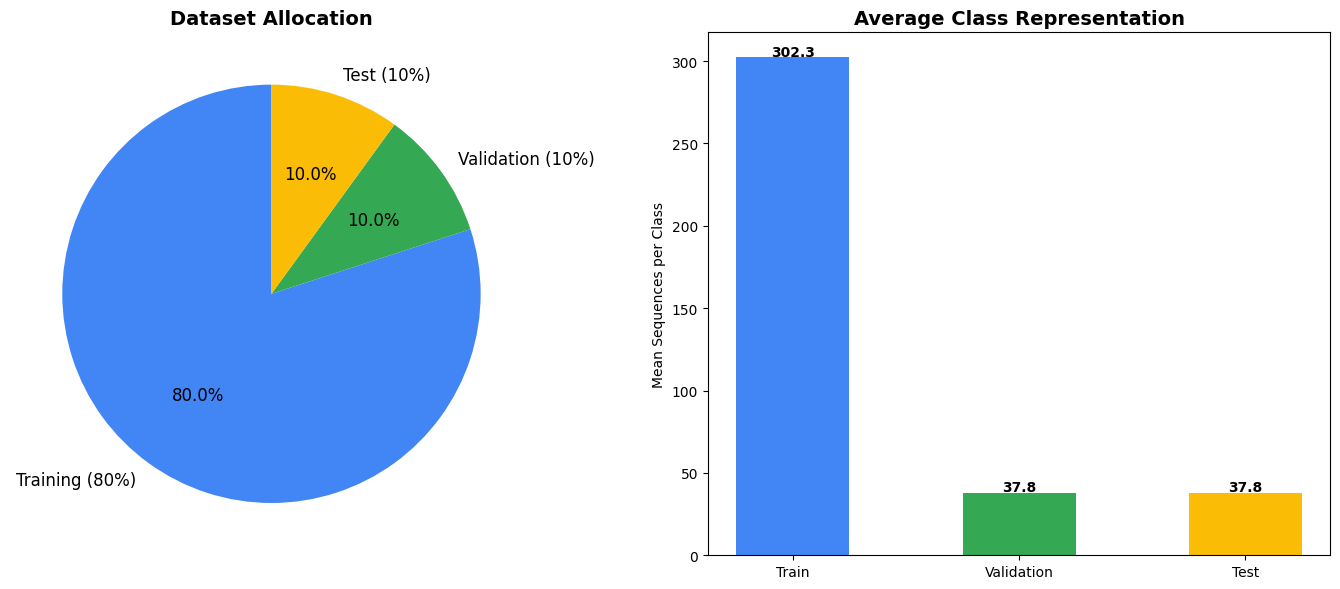

[2026-04-13 11:50:15] [BiGRU] [INFO]  Pre-training report saved.


In [15]:
_tc = train_df_split["label"].value_counts()
_vc = val_df_split  ["label"].value_counts()
_xc = test_df_split ["label"].value_counts()

_report = (
    f"=========================================================\n"
    f"       DATASET REPORT — {CFG.MODEL_NAME}\n"
    f"=========================================================\n"
    f"Total sequences         : {len(train_df)}\n"
    f"Unique classes          : {NUM_CLASSES}\n"
    f"Selected landmark nodes : {NUM_NODES}\n"
    f"Feature channels        : {CHANNELS}\n"
    f"Max sequence length     : {MAX_LEN} frames\n"
    f"Input tensor shape      : (Batch, {MAX_LEN}, {CHANNELS})\n"
    f"---------------------------------------------------------\n"
    f"Training   : {len(train_df_split)} samples\n"
    f"Validation : {len(val_df_split)} samples\n"
    f"Test       : {len(test_df_split)} samples\n"
    f"---------------------------------------------------------\n"
    f"[Train] max={_tc.max()}  min={_tc.min()}  mean={_tc.mean():.1f}\n"
    f"[Val]   max={_vc.max()}  min={_vc.min()}  mean={_vc.mean():.1f}\n"
    f"[Test]  max={_xc.max()}  min={_xc.min()}  mean={_xc.mean():.1f}\n"
    f"=========================================================\n"
)
logger.info(_report)

with open(os.path.join(DIRS["metrics"], "dataset_report.txt"), "w") as _f:
    _f.write(_report)

_fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(14, 6))
_ax1.pie(
    [len(train_df_split), len(val_df_split), len(test_df_split)],
    labels=["Training (80%)", "Validation (10%)", "Test (10%)"],
    colors=["#4285F4", "#34A853", "#FBBC05"],
    autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12},
)
_ax1.set_title("Dataset Allocation", fontsize=14, fontweight="bold")

_means = [_tc.mean(), _vc.mean(), _xc.mean()]
_ax2.bar(["Train", "Validation", "Test"], _means,
         color=["#4285F4", "#34A853", "#FBBC05"], width=0.5)
_ax2.set_ylabel("Mean Sequences per Class")
_ax2.set_title("Average Class Representation", fontsize=14, fontweight="bold")
for _i, _v in enumerate(_means):
    _ax2.text(_i, _v + 1, f"{_v:.1f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "data_split_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
logger.info("Pre-training report saved.")


## Section 16 — Evaluation Configuration

**The only thing you need to change is `MODEL_PATH` below.**  
Everything else is automatically inherited from the variables already in the notebook
(`test_dataset`, `test_steps`, `test_df_split`, `NUM_CLASSES`, `DIRS`, `CFG`, etc.).

In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         ONLY EDIT THIS LINE — paste your model path         ║
# ╚══════════════════════════════════════════════════════════════╝
MODEL_PATH = "/kaggle/input/models/hassanabdulrazeq/bigru/keras/default/1/BiGRU.keras"
# Accepted formats: .keras | .h5 | .hdf5 | SavedModel directory

# ── Everything below is auto-derived from the notebook variables ──────────────
class EVAL_CFG:
    MODEL_NAME      = CFG.MODEL_NAME          # "BiGRU"
    MODEL_PATH      = MODEL_PATH
    TOP_K           = 5                        # for top-k accuracy
    DPI             = 300                      # plot resolution
    CMAP            = "Blues"                  # confusion matrix colourmap
    SAVE_OUTPUTS    = True

    # Inherited paths
    PLOTS_DIR       = DIRS["plots"]
    METRICS_DIR     = DIRS["metrics"]
    PREDICTIONS_DIR = DIRS["predictions"]
    REPORTS_DIR     = os.path.join(DIRS["base"], "reports")

    # Inherited data variables
    DATASET         = test_dataset             # tf.data pipeline
    STEPS           = test_steps               # number of batches to consume
    HISTORY_PATH    = os.path.join(DIRS["metrics"], "history.json")
    OUTPUT_ROOT     = DIRS["base"]              # root used by the output-tree reporter

os.makedirs(EVAL_CFG.REPORTS_DIR, exist_ok=True)

logger.info("=" * 55)
logger.info("  EVALUATION PIPELINE — %s", EVAL_CFG.MODEL_NAME)
logger.info("  Model path : %s", EVAL_CFG.MODEL_PATH)
logger.info("  Test steps : %d  |  Num classes : %d", EVAL_CFG.STEPS, NUM_CLASSES)
logger.info("=" * 55)


[2026-04-13 11:50:15] [BiGRU] [INFO]  =======================================================
[2026-04-13 11:50:15] [BiGRU] [INFO]    EVALUATION PIPELINE — BiGRU
[2026-04-13 11:50:15] [BiGRU] [INFO]    Model path : /kaggle/input/models/hassanabdulrazeq/bigru/keras/default/1/BiGRU.keras
[2026-04-13 11:50:15] [BiGRU] [INFO]    Test steps : 73  |  Num classes : 250
[2026-04-13 11:50:15] [BiGRU] [INFO]  =======================================================


## Section 17 — Model Loading

Auto-detects `.keras`, `.h5 / .hdf5`, and SavedModel directory formats.  
Registers the custom `Preprocess` layer so it deserialises correctly.

In [17]:
@tf.keras.utils.register_keras_serializable(package="custom")
class MaskableConv1D(tf.keras.layers.Conv1D):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.supports_masking = True

@tf.keras.utils.register_keras_serializable(package="custom")
class Squeeze(tf.keras.layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.supports_masking = True
    def call(self, x):
        return tf.squeeze(x, axis=self.axis)
    def get_config(self):
        return {**super().get_config(), "axis": self.axis}

@tf.keras.utils.register_keras_serializable(package="custom")
class ExpandDims(tf.keras.layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.supports_masking = True
    def call(self, x):
        return tf.expand_dims(x, axis=self.axis)
    def get_config(self):
        return {**super().get_config(), "axis": self.axis}

@tf.keras.utils.register_keras_serializable(package="custom")
class ReduceSum(tf.keras.layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.supports_masking = True
    def call(self, x):
        return tf.reduce_sum(x, axis=self.axis)
    def get_config(self):
        return {**super().get_config(), "axis": self.axis}

@tf.keras.utils.register_keras_serializable(package="custom")
class MaskableGlobalMaxPool1D(tf.keras.layers.GlobalMaxPooling1D):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.supports_masking = True

logger.info("All custom layers registered.")


def load_model_flexible(path, custom_objects=None):
    """Load a Keras model — auto-detects .keras / .h5 / SavedModel."""
    if custom_objects is None:
        custom_objects = {
            "Preprocess":             Preprocess,
            "MaskableConv1D":         MaskableConv1D,
            "Squeeze":                Squeeze,
            "ExpandDims":             ExpandDims,
            "ReduceSum":              ReduceSum,
            "MaskableGlobalMaxPool1D": MaskableGlobalMaxPool1D,
        }
    path = str(path)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found: {path}")
    try:
        if path.endswith(".keras"):
            fmt = ".keras"
        elif path.endswith((".h5", ".hdf5")):
            fmt = ".h5"
        elif os.path.isdir(path):
            fmt = "SavedModel"
        else:
            fmt = "unknown (attempting generic load)"
        logger.info("Detected format: %s", fmt)
        model = tf.keras.models.load_model(path, custom_objects=custom_objects)
        logger.info("Model loaded successfully.")
        logger.info("Input  shape : %s", model.input_shape)
        logger.info("Output shape : %s", model.output_shape)
        logger.info("Total params : {:,}".format(model.count_params()))
        return model
    except Exception as exc:
        logger.error("Model loading failed: %s", exc)
        raise

try:
    eval_model = load_model_flexible(EVAL_CFG.MODEL_PATH)
except Exception as e:
    logger.error("Evaluation cannot proceed — model not loaded. Error: %s", e)
    eval_model = None

[2026-04-13 11:50:15] [BiGRU] [INFO]  All custom layers registered.
[2026-04-13 11:50:15] [BiGRU] [INFO]  Detected format: .keras
[2026-04-13 11:50:16] [BiGRU] [INFO]  Model loaded successfully.
[2026-04-13 11:50:16] [BiGRU] [INFO]  Input  shape : (None, 384, 708)
[2026-04-13 11:50:16] [BiGRU] [INFO]  Output shape : (None, 250)
[2026-04-13 11:50:16] [BiGRU] [INFO]  Total params : 2,435,451


## Section 18 — Collect Predictions

Runs inference over exactly `test_steps` batches from the existing
`test_dataset` pipeline and collects:
- `y_true` — integer ground-truth labels
- `y_pred` — argmax predictions
- `y_prob` — full softmax probability matrix  `(N, NUM_CLASSES)`

In [18]:
def collect_predictions(model, dataset, steps, num_classes=NUM_CLASSES):
    """Iterate `steps` batches and return (y_true, y_pred, y_prob)."""
    if model is None:
        raise RuntimeError("Model is not loaded.")
    all_true, all_prob = [], []
    logger.info("Running inference over %d batches ...", steps)
    for i, (x_batch, y_batch) in enumerate(dataset.take(steps)):
        try:
            probs = model.predict_on_batch(x_batch)
            labels = (tf.argmax(y_batch, axis=-1) if y_batch.shape.rank == 2
                      else y_batch).numpy().astype(int)
            all_true.append(labels)
            all_prob.append(probs)
        except Exception as exc:
            logger.warning("Batch %d skipped: %s", i, exc)
    if not all_true:
        raise RuntimeError("No predictions collected. Check test_dataset / test_steps.")
    y_true = np.concatenate(all_true).astype(int)
    y_prob = np.concatenate(all_prob).astype(np.float32)
    y_pred = np.argmax(y_prob, axis=-1).astype(int)
    logger.info("Collected %d samples | accuracy so far: %.4f",
                len(y_true), (y_true == y_pred).mean())
    return y_true, y_pred, y_prob

try:
    y_true, y_pred, y_prob = collect_predictions(
        eval_model, EVAL_CFG.DATASET, EVAL_CFG.STEPS)
except Exception as e:
    logger.error("Prediction collection failed: %s", e)
    y_true = y_pred = y_prob = None


[2026-04-13 11:50:16] [BiGRU] [INFO]  Running inference over 73 batches ...
[2026-04-13 12:01:39] [BiGRU] [INFO]  Collected 9344 samples | accuracy so far: 0.8159


## Section 18b — Inference Performance Analysis

Measures GPU/CPU latency and throughput over a representative slice of the test set.
A warm-up pass is executed before timing to avoid first-call JIT overhead.
Results are stored in `inference_performance.csv` alongside the other evaluation artefacts.
This section does not alter `y_true`, `y_pred`, or `y_prob`.

In [19]:
# =============================================================================
# Section 18b — Inference Performance Analysis
# Additive section: does NOT modify y_true / y_pred / y_prob.
# Uses model(x, training=False) for direct call timing under mixed precision.
# =============================================================================

def measure_inference_performance(model, dataset, warmup_steps=3, measure_steps=20):
    """
    Warm up the model, then time a fixed number of batches.

    Parameters
    ----------
    model         : loaded Keras model
    dataset       : tf.data.Dataset (already batched and padded)
    warmup_steps  : silent batches before timing (avoids JIT / graph-compile overhead)
    measure_steps : batches used for the timed measurement

    Returns
    -------
    dict — latency statistics and throughput
    """
    if model is None:
        logger.warning("Model not loaded — skipping inference timing.")
        return None

    device_tag = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"

    # Warm-up pass
    logger.info("Inference timing warm-up: %d batches on %s ...", warmup_steps, device_tag)
    for x_batch, _ in dataset.take(warmup_steps):
        _ = model(x_batch, training=False)

    # Timed measurement
    batch_times = []
    batch_sizes = []
    logger.info("Timing inference over %d batches ...", measure_steps)

    for x_batch, _ in dataset.take(measure_steps):
        t0  = time.perf_counter()
        out = model(x_batch, training=False)
        # Force GPU synchronisation: .numpy() blocks until the op completes
        try:
            out.numpy()
        except Exception:
            pass
        t1 = time.perf_counter()
        batch_times.append((t1 - t0) * 1000.0)   # milliseconds
        batch_sizes.append(int(x_batch.shape[0]))

    batch_times   = np.array(batch_times)
    batch_sizes   = np.array(batch_sizes)
    total_samples = float(batch_sizes.sum())
    total_ms      = float(batch_times.sum())
    throughput    = (total_samples / total_ms) * 1000.0   # samples / second

    result = {
        "device":             device_tag,
        "batch_size":         int(batch_sizes[0]),
        "warmup_batches":     warmup_steps,
        "measured_batches":   measure_steps,
        "total_samples":      int(total_samples),
        "mean_batch_lat_ms":  round(float(batch_times.mean()), 3),
        "std_batch_lat_ms":   round(float(batch_times.std()),  3),
        "per_sample_lat_ms":  round(float(batch_times.mean()) / float(batch_sizes.mean()), 4),
        "throughput_sps":     round(throughput, 1),
    }

    line = "=" * 58
    txt  = f"\n{line}\n  INFERENCE PERFORMANCE — {EVAL_CFG.MODEL_NAME}\n{line}\n"
    for k, v in result.items():
        txt += f"  {k:<26}: {v}\n"
    txt += f"{line}\n"
    print(txt)
    logger.info(txt)

    pd.DataFrame([result]).to_csv(
        os.path.join(EVAL_CFG.METRICS_DIR, "inference_performance.csv"), index=False
    )
    logger.info("Inference performance metrics saved.")
    return result


try:
    perf_metrics = measure_inference_performance(
        eval_model, EVAL_CFG.DATASET,
        warmup_steps=3, measure_steps=20,
    )
except Exception as e:
    logger.error("Inference performance measurement failed: %s", e)
    perf_metrics = None


[2026-04-13 12:01:39] [BiGRU] [INFO]  Inference timing warm-up: 3 batches on CPU ...


2026-04-13 12:01:39.753123: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}


[2026-04-13 12:02:46] [BiGRU] [INFO]  Timing inference over 20 batches ...


2026-04-13 12:02:46.768529: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}



  INFERENCE PERFORMANCE — BiGRU
  device                    : CPU
  batch_size                : 128
  warmup_batches            : 3
  measured_batches          : 20
  total_samples             : 2560
  mean_batch_lat_ms         : 19422.806
  std_batch_lat_ms          : 213.592
  per_sample_lat_ms         : 151.7407
  throughput_sps            : 6.6

[2026-04-13 12:09:40] [BiGRU] [INFO]  
  INFERENCE PERFORMANCE — BiGRU
  device                    : CPU
  batch_size                : 128
  warmup_batches            : 3
  measured_batches          : 20
  total_samples             : 2560
  mean_batch_lat_ms         : 19422.806
  std_batch_lat_ms          : 213.592
  per_sample_lat_ms         : 151.7407
  throughput_sps            : 6.6

[2026-04-13 12:09:40] [BiGRU] [INFO]  Inference performance metrics saved.


## Section 18c — Model Size Analysis

Reports total, trainable, and non-trainable parameter counts together with an
estimate of the model's weight memory footprint and its on-disk size.
This is a static analysis — no data pipeline is touched.

In [20]:
# =============================================================================
# Section 18c — Model Size Analysis
# =============================================================================

def analyze_model_size(model, model_path=None):
    """
    Compute and report parameter counts and estimated memory footprint.

    Parameters
    ----------
    model      : loaded Keras model
    model_path : optional path string — used to report on-disk file size

    Returns
    -------
    dict
    """
    if model is None:
        logger.warning("Model not loaded — skipping size analysis.")
        return None

    total_params    = model.count_params()
    trainable_p     = sum(tf.keras.backend.count_params(w)
                          for w in model.trainable_weights)
    non_trainable_p = total_params - trainable_p
    weight_mb       = (total_params * 4) / (1024 ** 2)   # float32 = 4 bytes each

    disk_mb = None
    if model_path and os.path.exists(str(model_path)):
        disk_mb = round(os.path.getsize(str(model_path)) / (1024 ** 2), 2)

    result = {
        "model":                  EVAL_CFG.MODEL_NAME,
        "total_parameters":       total_params,
        "trainable_parameters":   trainable_p,
        "non_trainable_params":   non_trainable_p,
        "weight_footprint_mb":    round(weight_mb, 2),
        "disk_size_mb":           disk_mb,
    }

    line = "=" * 58
    txt  = f"\n{line}\n  MODEL SIZE — {EVAL_CFG.MODEL_NAME}\n{line}\n"
    for k, v in result.items():
        txt += f"  {k:<28}: {v}\n"
    txt += f"{line}\n"
    print(txt)
    logger.info(txt)

    pd.DataFrame([result]).to_csv(
        os.path.join(EVAL_CFG.METRICS_DIR, "model_size.csv"), index=False
    )
    logger.info("Model size metrics saved.")
    return result


try:
    size_metrics = analyze_model_size(eval_model, EVAL_CFG.MODEL_PATH)
except Exception as e:
    logger.error("Model size analysis failed: %s", e)
    size_metrics = None



  MODEL SIZE — BiGRU
  model                       : BiGRU
  total_parameters            : 2435451
  trainable_parameters        : 2434427
  non_trainable_params        : 1024
  weight_footprint_mb         : 9.29
  disk_size_mb                : 9.41

[2026-04-13 12:09:40] [BiGRU] [INFO]  
  MODEL SIZE — BiGRU
  model                       : BiGRU
  total_parameters            : 2435451
  trainable_parameters        : 2434427
  non_trainable_params        : 1024
  weight_footprint_mb         : 9.29
  disk_size_mb                : 9.41

[2026-04-13 12:09:40] [BiGRU] [INFO]  Model size metrics saved.


## Section 19 — Class Names

Resolves human-readable class names from the label map already built
during data preparation (`label_to_sign` → `sign_list` → integer fallback).

In [21]:
try:
    class_names = [label_to_sign[i] for i in range(NUM_CLASSES)]
    logger.info("Class names from label_to_sign (%d classes).", NUM_CLASSES)
except NameError:
    try:
        class_names = list(sign_list)
        logger.info("Class names from sign_list (%d classes).", len(class_names))
    except NameError:
        class_names = [str(i) for i in range(NUM_CLASSES)]
        logger.warning("Falling back to integer class names.")

assert len(class_names) == NUM_CLASSES


[2026-04-13 12:09:40] [BiGRU] [INFO]  Class names from label_to_sign (250 classes).


## Section 20 — Confusion Matrix

Saves both a **raw count** and a **row-normalised** confusion matrix at 300 DPI.

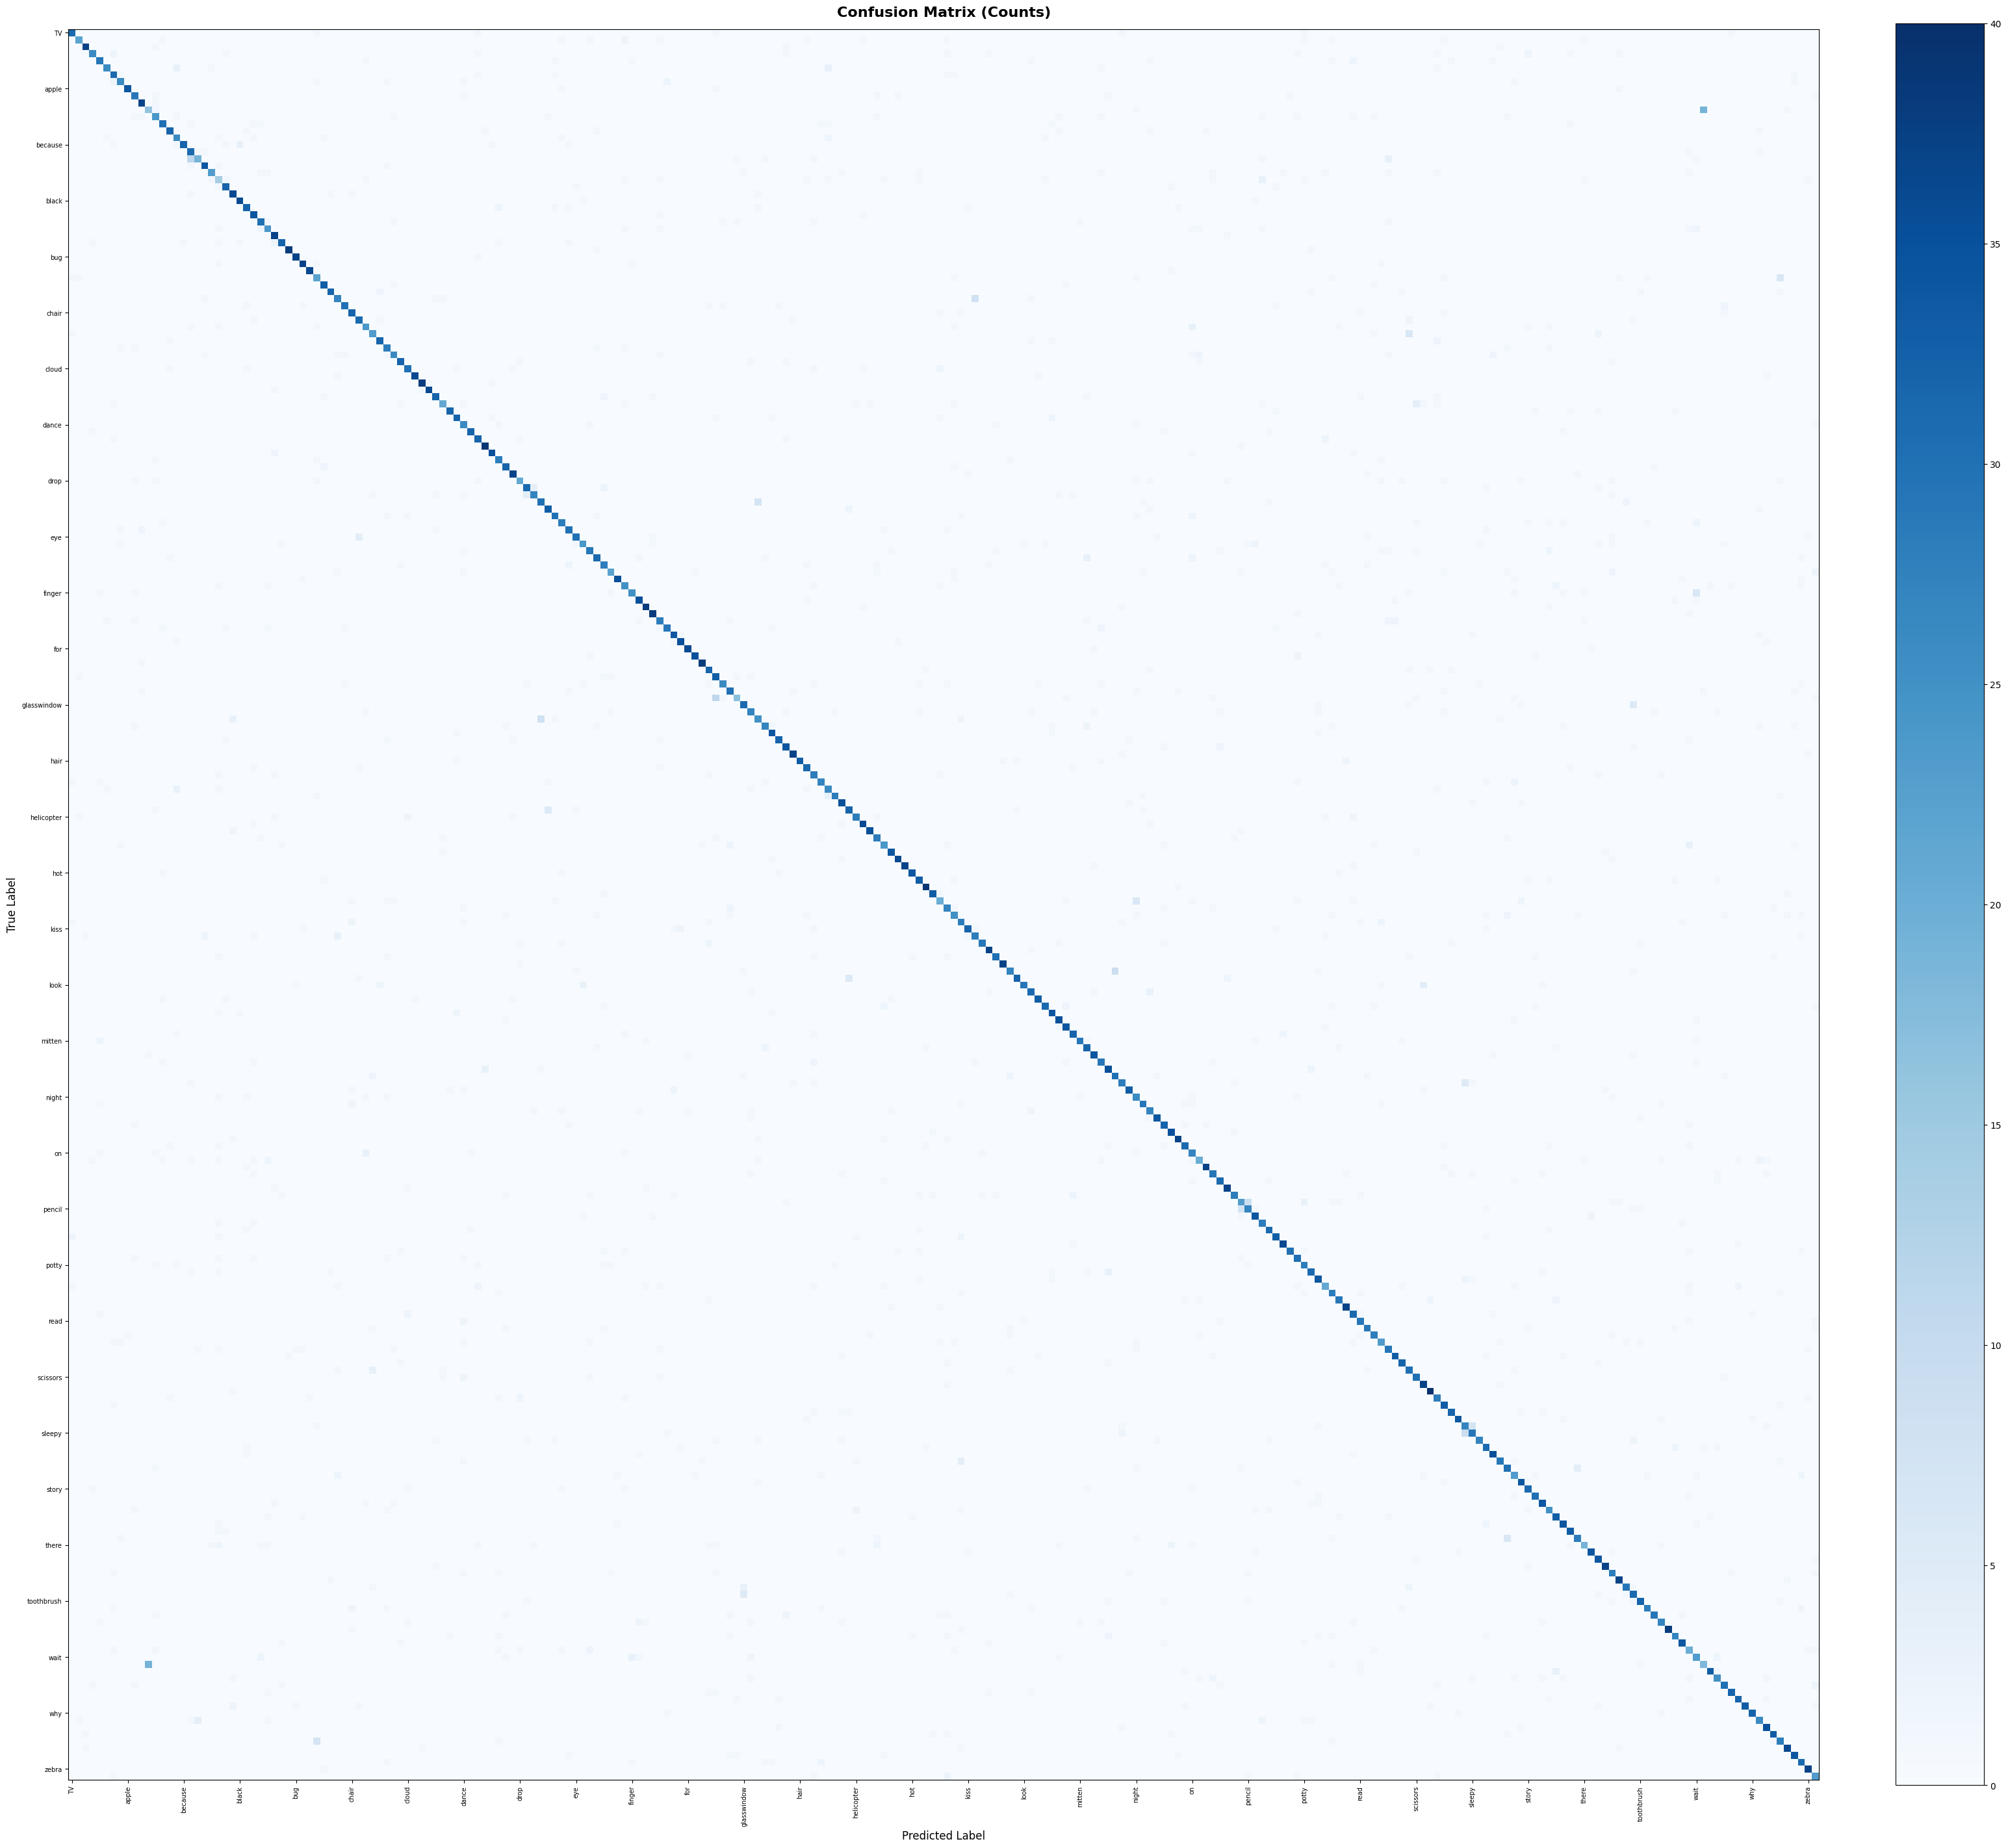

[2026-04-13 12:09:52] [BiGRU] [INFO]  Saved: /kaggle/working/BiGRU/plots/confusion_matrix_raw.png


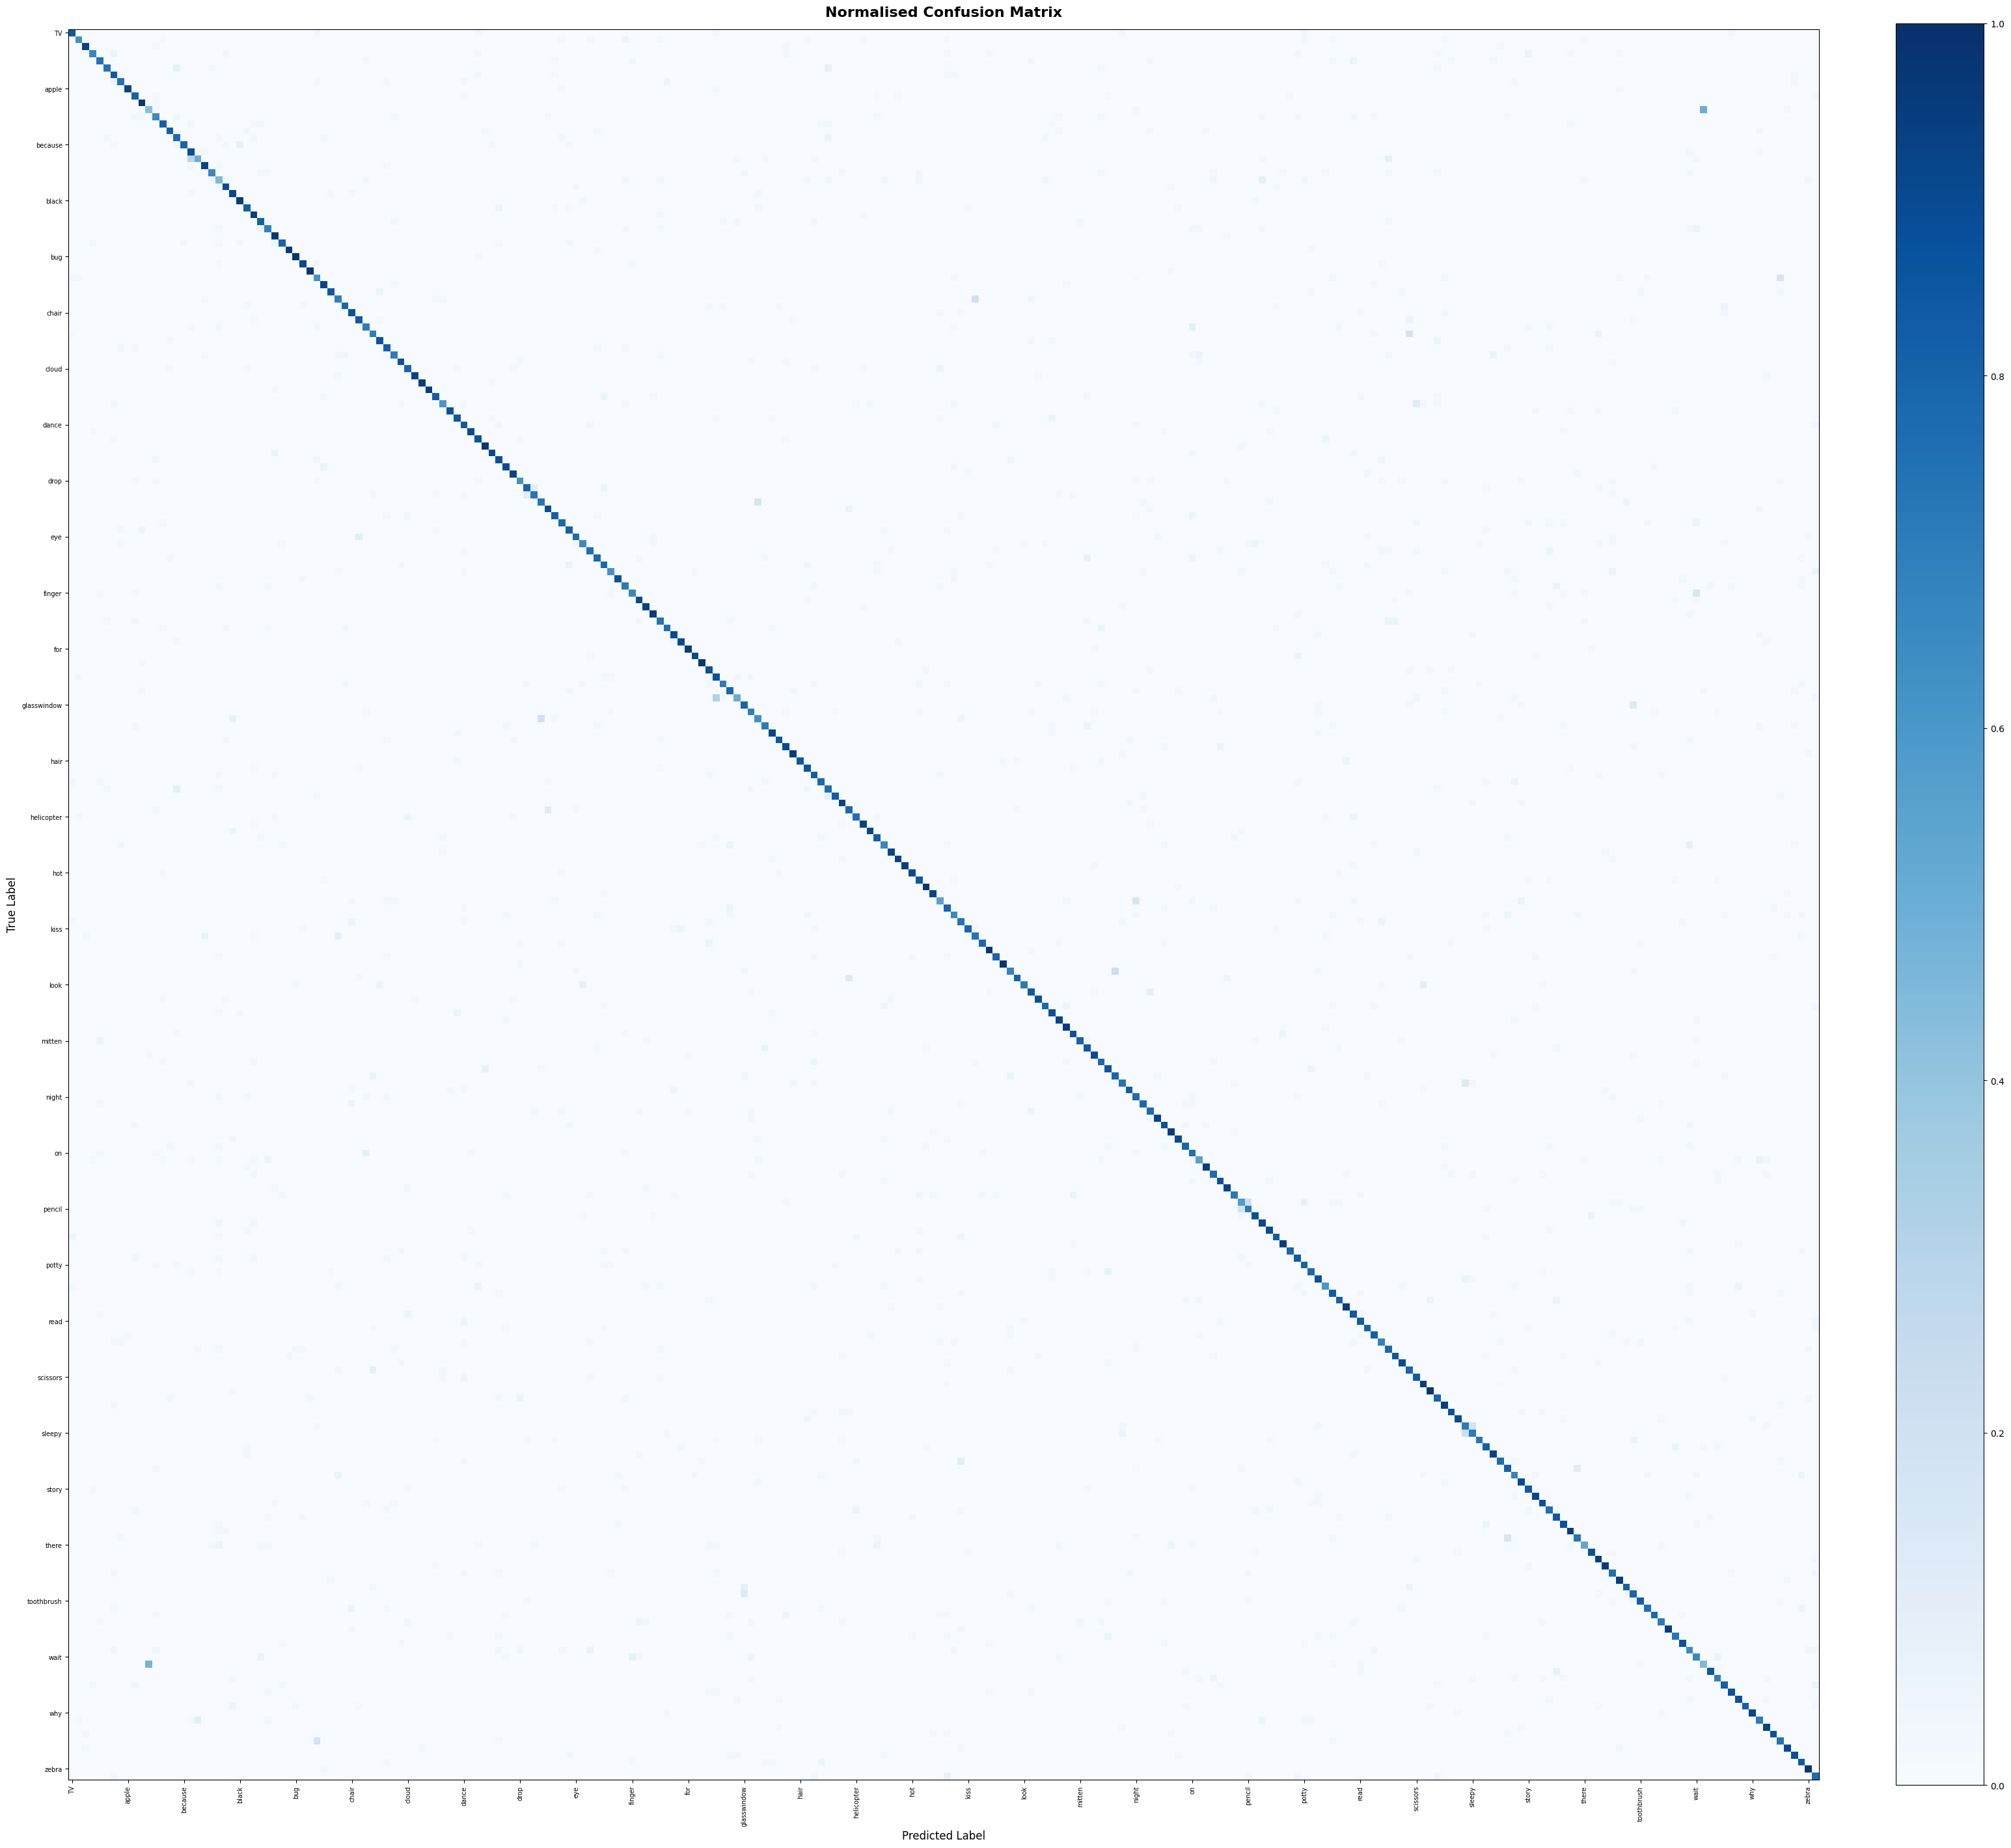

[2026-04-13 12:10:05] [BiGRU] [INFO]  Saved: /kaggle/working/BiGRU/plots/confusion_matrix_normalized.png


In [22]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_names, save_dir,
                          normalize=False, dpi=300, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    if normalize:
        with np.errstate(divide="ignore", invalid="ignore"):
            cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            cm_plot = np.nan_to_num(cm_plot)
        title, fmt, fname = "Normalised Confusion Matrix", ".2f", "confusion_matrix_normalized.png"
    else:
        cm_plot, title, fmt, fname = cm, "Confusion Matrix (Counts)", "d", "confusion_matrix_raw.png"

    n = len(class_names)
    fig_sz = max(12, n // 8)
    fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))
    im = ax.imshow(cm_plot, cmap=cmap, vmin=0,
                   vmax=1.0 if normalize else cm_plot.max())
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    step = max(1, n // 30)
    ticks = list(range(0, n, step))
    ax.set_xticks(ticks); ax.set_xticklabels([class_names[i] for i in ticks], rotation=90, fontsize=7)
    ax.set_yticks(ticks); ax.set_yticklabels([class_names[i] for i in ticks], fontsize=7)
    plt.tight_layout()
    path = os.path.join(save_dir, fname)
    plt.savefig(path, dpi=dpi, bbox_inches="tight"); plt.show()
    logger.info("Saved: %s", path)
    return cm

if y_true is not None:
    try:
        cm_raw  = plot_confusion_matrix(y_true, y_pred, class_names,
                                        EVAL_CFG.PLOTS_DIR, normalize=False,
                                        dpi=EVAL_CFG.DPI, cmap=EVAL_CFG.CMAP)
        cm_norm = plot_confusion_matrix(y_true, y_pred, class_names,
                                        EVAL_CFG.PLOTS_DIR, normalize=True,
                                        dpi=EVAL_CFG.DPI, cmap=EVAL_CFG.CMAP)
    except Exception as e:
        logger.error("Confusion matrix failed: %s", e)


## Section 21 — Classification Report

Per-class Precision / Recall / F1 saved as **CSV** and **TXT**.

In [23]:
from sklearn.metrics import classification_report

def save_classification_report(y_true, y_pred, class_names, metrics_dir, reports_dir):
    report_dict = classification_report(
        y_true, y_pred, labels=range(len(class_names)),
        target_names=class_names, output_dict=True, zero_division=0)
    report_txt = classification_report(
        y_true, y_pred, labels=range(len(class_names)),
        target_names=class_names, zero_division=0)

    txt_path = os.path.join(reports_dir, "classification_report.txt")
    with open(txt_path, "w") as f:
        f.write(f"Classification Report — {EVAL_CFG.MODEL_NAME}\n" + "="*70 + "\n")
        f.write(report_txt)
    logger.info("Saved: %s", txt_path)

    rows = [{"class": k, **v} for k, v in report_dict.items() if isinstance(v, dict)]
    report_df = pd.DataFrame(rows)
    csv_path = os.path.join(metrics_dir, "classification_report.csv")
    report_df.to_csv(csv_path, index=False)
    logger.info("Saved: %s", csv_path)
    print(report_txt)
    return report_df

if y_true is not None:
    try:
        report_df = save_classification_report(
            y_true, y_pred, class_names,
            EVAL_CFG.METRICS_DIR, EVAL_CFG.REPORTS_DIR)
    except Exception as e:
        logger.error("Classification report failed: %s", e)
        report_df = None


[2026-04-13 12:10:05] [BiGRU] [INFO]  Saved: /kaggle/working/BiGRU/reports/classification_report.txt
[2026-04-13 12:10:05] [BiGRU] [INFO]  Saved: /kaggle/working/BiGRU/metrics/classification_report.csv
              precision    recall  f1-score   support

          TV       0.82      0.84      0.83        37
       after       0.85      0.63      0.72        35
    airplane       0.93      0.93      0.93        40
         all       0.84      0.67      0.74        39
   alligator       0.78      0.74      0.76        39
      animal       0.90      0.74      0.81        35
     another       0.70      0.84      0.77        37
         any       0.79      0.74      0.76        35
       apple       0.97      0.92      0.94        37
         arm       0.74      0.81      0.77        36
        aunt       0.88      0.97      0.93        38
       awake       0.44      0.42      0.43        38
    backyard       0.67      0.65      0.66        37
         bad       0.81      0.81      0.

## Section 22 — Per-Class Performance Analysis

Per-class accuracy bar chart showing the **top-20** and **bottom-20** classes.

[2026-04-13 12:10:05] [BiGRU] [INFO]  Best  class : shhh (0.9756)
[2026-04-13 12:10:05] [BiGRU] [INFO]  Worst class : awake (0.4211)


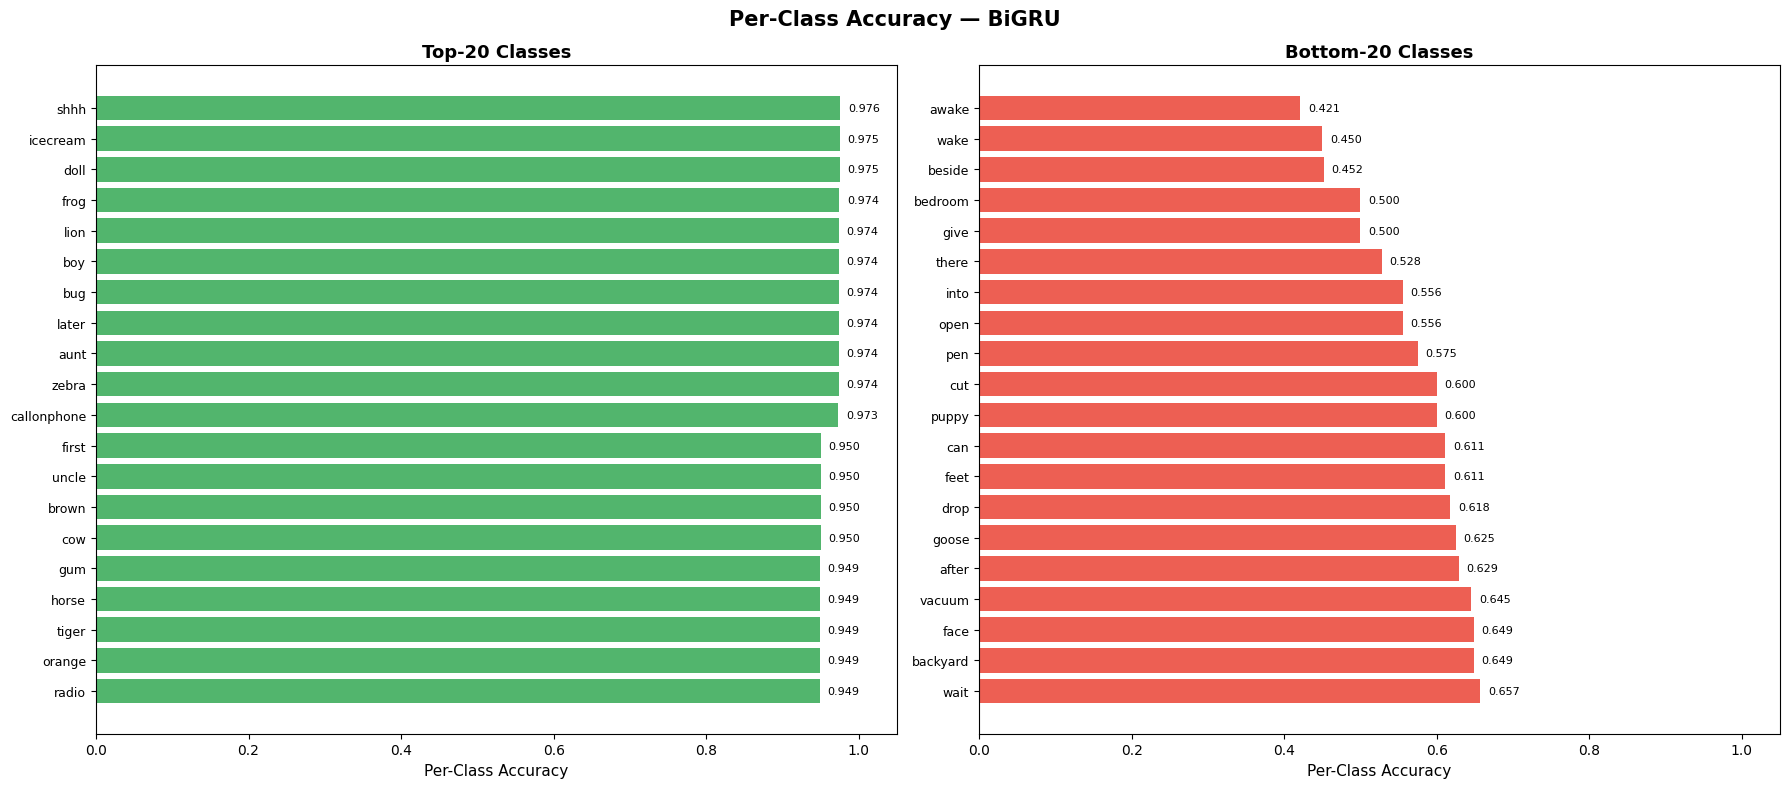

[2026-04-13 12:10:07] [BiGRU] [INFO]  Saved: /kaggle/working/BiGRU/plots/per_class_accuracy.png


In [24]:
def analyze_per_class_performance(y_true, y_pred, class_names, plots_dir,
                                  metrics_dir, dpi=300, top_n=20):
    n = len(class_names)
    per_class_acc = np.array([
        (y_pred[y_true == c] == c).mean() if (y_true == c).any() else 0.0
        for c in range(n)
    ])
    sorted_idx = np.argsort(per_class_acc)
    worst_idx  = sorted_idx[:top_n]
    best_idx   = sorted_idx[-top_n:][::-1]
    logger.info("Best  class : %s (%.4f)", class_names[best_idx[0]],  per_class_acc[best_idx[0]])
    logger.info("Worst class : %s (%.4f)", class_names[worst_idx[0]], per_class_acc[worst_idx[0]])

    pd.DataFrame({"class": class_names, "per_class_accuracy": per_class_acc})       .sort_values("per_class_accuracy", ascending=False)       .to_csv(os.path.join(metrics_dir, "per_class_accuracy.csv"), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    for ax, idx, label, color in [
        (axes[0], best_idx,  f"Top-{top_n} Classes",    "#34A853"),
        (axes[1], worst_idx, f"Bottom-{top_n} Classes", "#EA4335"),
    ]:
        vals  = per_class_acc[idx]
        names = [class_names[i] for i in idx]
        bars  = ax.barh(range(len(idx)), vals, color=color, alpha=0.85)
        ax.set_yticks(range(len(idx))); ax.set_yticklabels(names, fontsize=9)
        ax.set_xlabel("Per-Class Accuracy", fontsize=11)
        ax.set_title(label, fontsize=13, fontweight="bold")
        ax.set_xlim(0, 1.05); ax.invert_yaxis()
        for bar, v in zip(bars, vals):
            ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                    f"{v:.3f}", va="center", fontsize=8)

    plt.suptitle(f"Per-Class Accuracy — {EVAL_CFG.MODEL_NAME}",
                 fontsize=15, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(plots_dir, "per_class_accuracy.png")
    plt.savefig(path, dpi=dpi, bbox_inches="tight"); plt.show()
    logger.info("Saved: %s", path)
    return per_class_acc

if y_true is not None:
    try:
        per_class_acc = analyze_per_class_performance(
            y_true, y_pred, class_names,
            EVAL_CFG.PLOTS_DIR, EVAL_CFG.METRICS_DIR, dpi=EVAL_CFG.DPI)
    except Exception as e:
        logger.error("Per-class analysis failed: %s", e)
        per_class_acc = None


## Section 23 — Metrics Distribution

Distribution histograms of per-class Precision, Recall, and F1-score.

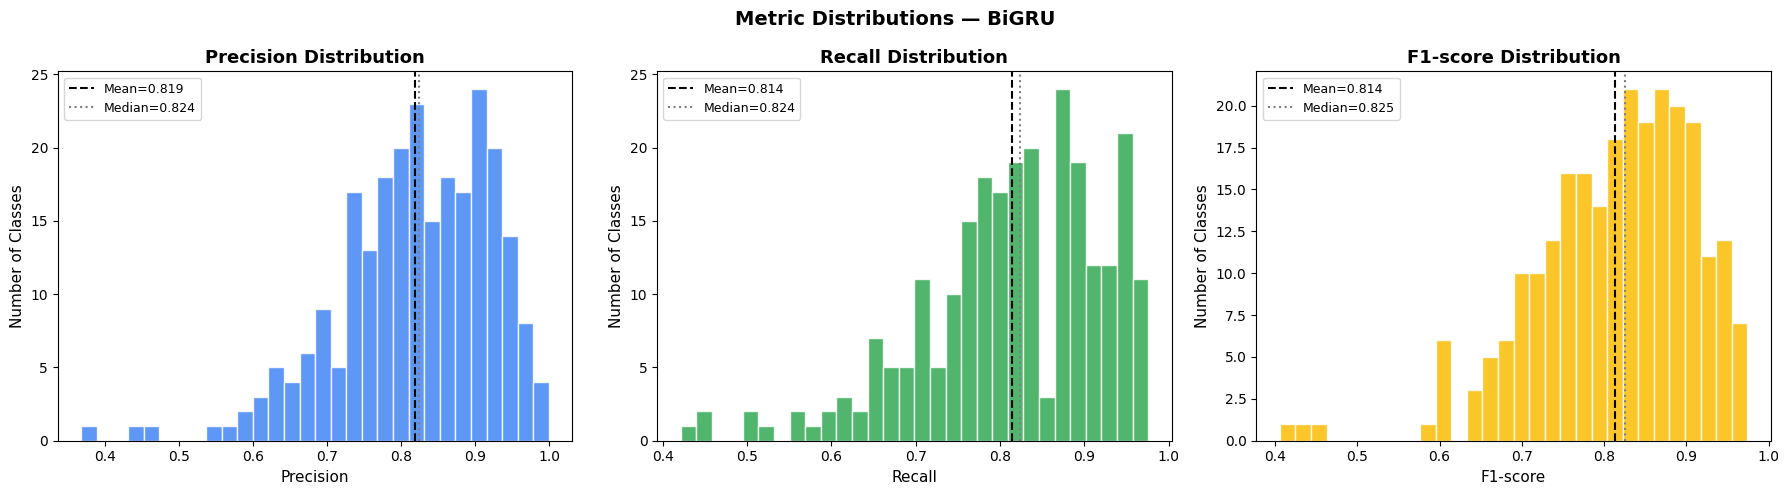

[2026-04-13 12:10:08] [BiGRU] [INFO]  Saved: /kaggle/working/BiGRU/plots/metrics_distribution.png


In [25]:
def plot_metrics_distribution(report_df, plots_dir, model_name, dpi=300):
    per_class = report_df[~report_df["class"].isin(
        ["accuracy", "macro avg", "weighted avg"])].copy()
    metrics = ["precision", "recall", "f1-score"]
    colors  = ["#4285F4", "#34A853", "#FBBC05"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric, color in zip(axes, metrics, colors):
        vals = per_class[metric].dropna()
        ax.hist(vals, bins=30, color=color, edgecolor="white", alpha=0.85)
        ax.axvline(vals.mean(),   color="black", ls="--", lw=1.5, label=f"Mean={vals.mean():.3f}")
        ax.axvline(vals.median(), color="gray",  ls=":",  lw=1.5, label=f"Median={vals.median():.3f}")
        ax.set_xlabel(metric.capitalize(), fontsize=11)
        ax.set_ylabel("Number of Classes", fontsize=11)
        ax.set_title(f"{metric.capitalize()} Distribution", fontsize=13, fontweight="bold")
        ax.legend(fontsize=9)
    plt.suptitle(f"Metric Distributions — {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(plots_dir, "metrics_distribution.png")
    plt.savefig(path, dpi=dpi, bbox_inches="tight"); plt.show()
    logger.info("Saved: %s", path)

if y_true is not None and report_df is not None:
    try:
        plot_metrics_distribution(report_df, EVAL_CFG.PLOTS_DIR,
                                  EVAL_CFG.MODEL_NAME, dpi=EVAL_CFG.DPI)
    except Exception as e:
        logger.error("Metrics distribution failed: %s", e)


## Section 24 — ROC Curves (One-vs-Rest, Memory-Efficient)

AUC is computed class-by-class to avoid materialising a full `(N × C)` boolean matrix.

[2026-04-13 12:10:09] [BiGRU] [INFO]  Macro ROC-AUC: 0.9881


/tmp/ipykernel_16/3098909610.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_roc = plt.cm.get_cmap("tab20", max_curves)


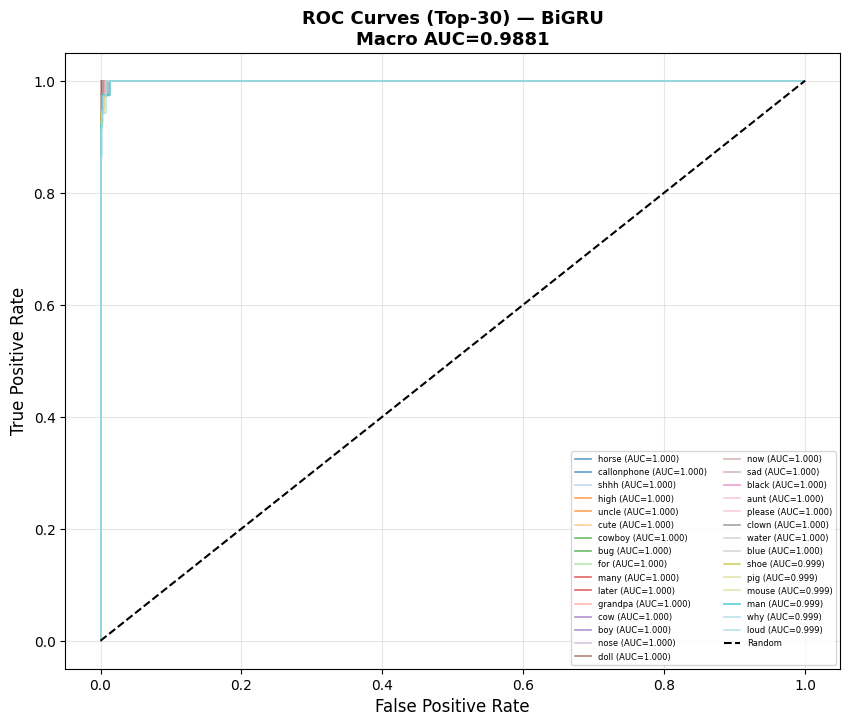

[2026-04-13 12:10:11] [BiGRU] [INFO]  Saved: /kaggle/working/BiGRU/plots/roc_curves.png


In [26]:
from sklearn.metrics import roc_curve, auc

def compute_and_plot_roc(y_true, y_prob, class_names, plots_dir, metrics_dir,
                         model_name, dpi=300, max_curves=30):
    n = len(class_names)
    auc_scores = np.zeros(n)
    for c in range(n):
        binary = (y_true == c).astype(int)
        if binary.sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(binary, y_prob[:, c])
        auc_scores[c] = auc(fpr, tpr)
    macro_auc = auc_scores[auc_scores > 0].mean()
    logger.info("Macro ROC-AUC: %.4f", macro_auc)

    pd.DataFrame({"class": class_names, "roc_auc": auc_scores})       .to_csv(os.path.join(metrics_dir, "roc_auc_per_class.csv"), index=False)

    top_idx  = np.argsort(auc_scores)[-max_curves:][::-1]
    cmap_roc = plt.cm.get_cmap("tab20", max_curves)
    fig, ax  = plt.subplots(figsize=(10, 8))
    for rank, c in enumerate(top_idx):
        binary = (y_true == c).astype(int)
        if binary.sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(binary, y_prob[:, c])
        ax.plot(fpr, tpr, lw=1.2, alpha=0.7, color=cmap_roc(rank),
                label=f"{class_names[c]} (AUC={auc_scores[c]:.3f})")
    ax.plot([0,1],[0,1],"k--",lw=1.5,label="Random")
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate",  fontsize=12)
    ax.set_title(f"ROC Curves (Top-{max_curves}) — {model_name}\nMacro AUC={macro_auc:.4f}",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=6, ncol=2)
    ax.grid(alpha=0.3)
    path = os.path.join(plots_dir, "roc_curves.png")
    plt.savefig(path, dpi=dpi, bbox_inches="tight"); plt.show()
    logger.info("Saved: %s", path)
    return auc_scores, macro_auc

if y_true is not None:
    try:
        auc_scores, macro_auc = compute_and_plot_roc(
            y_true, y_prob, class_names,
            EVAL_CFG.PLOTS_DIR, EVAL_CFG.METRICS_DIR,
            EVAL_CFG.MODEL_NAME, dpi=EVAL_CFG.DPI)
    except Exception as e:
        logger.error("ROC curves failed: %s", e)
        auc_scores = macro_auc = None


## Section 25 — Precision-Recall Curves

Multi-class PR curves with per-class Average Precision (PR-AUC).

[2026-04-13 12:10:11] [BiGRU] [INFO]  Macro PR-AUC: 0.8410


/tmp/ipykernel_16/2545246308.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_pr = plt.cm.get_cmap("tab20", max_curves)


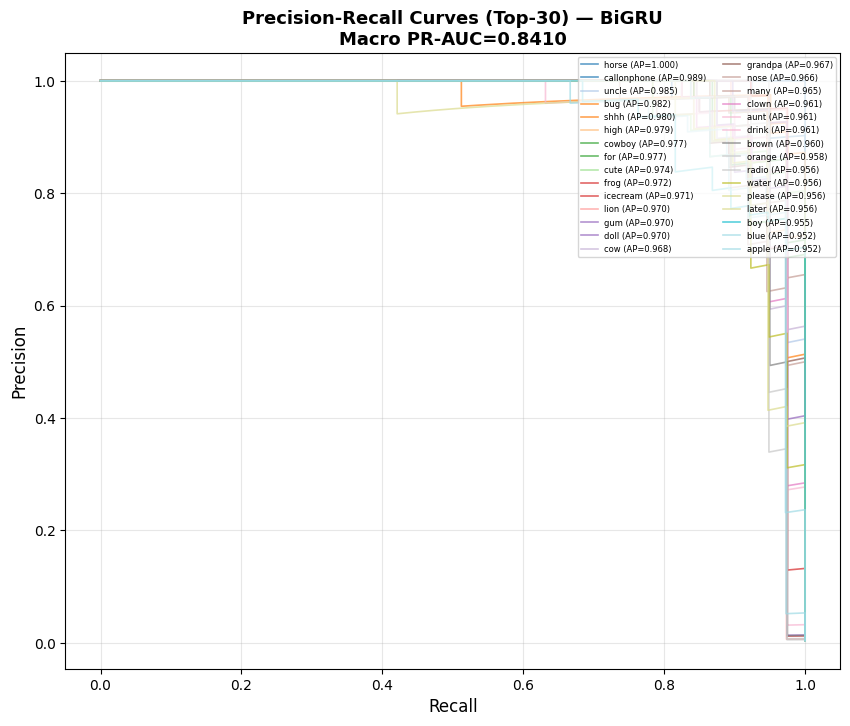

[2026-04-13 12:10:13] [BiGRU] [INFO]  Saved: /kaggle/working/BiGRU/plots/precision_recall_curves.png


In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def compute_and_plot_pr(y_true, y_prob, class_names, plots_dir, metrics_dir,
                        model_name, dpi=300, max_curves=30):
    n = len(class_names)
    pr_auc = np.zeros(n)
    for c in range(n):
        binary = (y_true == c).astype(int)
        if binary.sum() > 0:
            pr_auc[c] = average_precision_score(binary, y_prob[:, c])
    macro_pr_auc = pr_auc[pr_auc > 0].mean()
    logger.info("Macro PR-AUC: %.4f", macro_pr_auc)

    pd.DataFrame({"class": class_names, "pr_auc": pr_auc})       .to_csv(os.path.join(metrics_dir, "pr_auc_per_class.csv"), index=False)

    top_idx = np.argsort(pr_auc)[-max_curves:][::-1]
    cmap_pr = plt.cm.get_cmap("tab20", max_curves)
    fig, ax = plt.subplots(figsize=(10, 8))
    for rank, c in enumerate(top_idx):
        binary = (y_true == c).astype(int)
        if binary.sum() == 0:
            continue
        prec, rec, _ = precision_recall_curve(binary, y_prob[:, c])
        ax.plot(rec, prec, lw=1.2, alpha=0.7, color=cmap_pr(rank),
                label=f"{class_names[c]} (AP={pr_auc[c]:.3f})")
    ax.set_xlabel("Recall",    fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title(f"Precision-Recall Curves (Top-{max_curves}) — {model_name}\n"
                 f"Macro PR-AUC={macro_pr_auc:.4f}", fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=6, ncol=2)
    ax.grid(alpha=0.3)
    path = os.path.join(plots_dir, "precision_recall_curves.png")
    plt.savefig(path, dpi=dpi, bbox_inches="tight"); plt.show()
    logger.info("Saved: %s", path)
    return pr_auc, macro_pr_auc

if y_true is not None:
    try:
        pr_auc_scores, macro_pr_auc = compute_and_plot_pr(
            y_true, y_prob, class_names,
            EVAL_CFG.PLOTS_DIR, EVAL_CFG.METRICS_DIR,
            EVAL_CFG.MODEL_NAME, dpi=EVAL_CFG.DPI)
    except Exception as e:
        logger.error("Precision-Recall curves failed: %s", e)
        pr_auc_scores = macro_pr_auc = None


## Section 26 — Training History (Optional)

Silently skipped if no `history.json` is found. Otherwise plots loss and accuracy curves.

In [28]:
def plot_training_history(history_path, plots_dir, model_name, dpi=300):
    if not os.path.exists(history_path):
        logger.info("No history file at %s — skipping.", history_path)
        return
    with open(history_path) as f:
        history = json.load(f)
    epochs   = range(1, len(next(iter(history.values()))) + 1)
    acc_key  = "accuracy"     if "accuracy"     in history else "acc"
    val_acc  = "val_accuracy" if "val_accuracy" in history else "val_acc"
    has_loss = "loss"    in history
    has_acc  = acc_key   in history
    n_plots  = int(has_loss) + int(has_acc)
    if n_plots == 0:
        logger.warning("No recognised keys in history JSON.")
        return
    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))
    if n_plots == 1: axes = [axes]
    idx = 0
    if has_loss:
        ax = axes[idx]; idx += 1
        ax.plot(epochs, history["loss"], label="Train Loss", color="#4285F4", lw=2)
        if "val_loss" in history:
            ax.plot(epochs, history["val_loss"], label="Val Loss", color="#EA4335", lw=2, ls="--")
        ax.set_title("Loss Curve", fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(); ax.grid(alpha=0.3)
    if has_acc:
        ax = axes[idx]
        ax.plot(epochs, history[acc_key], label="Train Acc", color="#34A853", lw=2)
        if val_acc in history:
            ax.plot(epochs, history[val_acc], label="Val Acc", color="#FBBC05", lw=2, ls="--")
        ax.set_title("Accuracy Curve", fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(f"Training History — {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(plots_dir, "training_history.png")
    plt.savefig(path, dpi=dpi, bbox_inches="tight"); plt.show()
    logger.info("Saved: %s", path)

try:
    plot_training_history(EVAL_CFG.HISTORY_PATH, EVAL_CFG.PLOTS_DIR,
                          EVAL_CFG.MODEL_NAME, dpi=EVAL_CFG.DPI)
except Exception as e:
    logger.error("Training history failed: %s", e)


[2026-04-13 12:10:13] [BiGRU] [INFO]  No history file at /kaggle/working/BiGRU/metrics/history.json — skipping.


## Section 27 — Error Analysis

1. **Misclassified samples** — saved to CSV  
2. **Most confused class pairs** — bar chart  
3. **Hard examples** — correctly predicted but with lowest confidence

[2026-04-13 12:10:13] [BiGRU] [INFO]  Errors: 1720 / 9344  (18.41%)


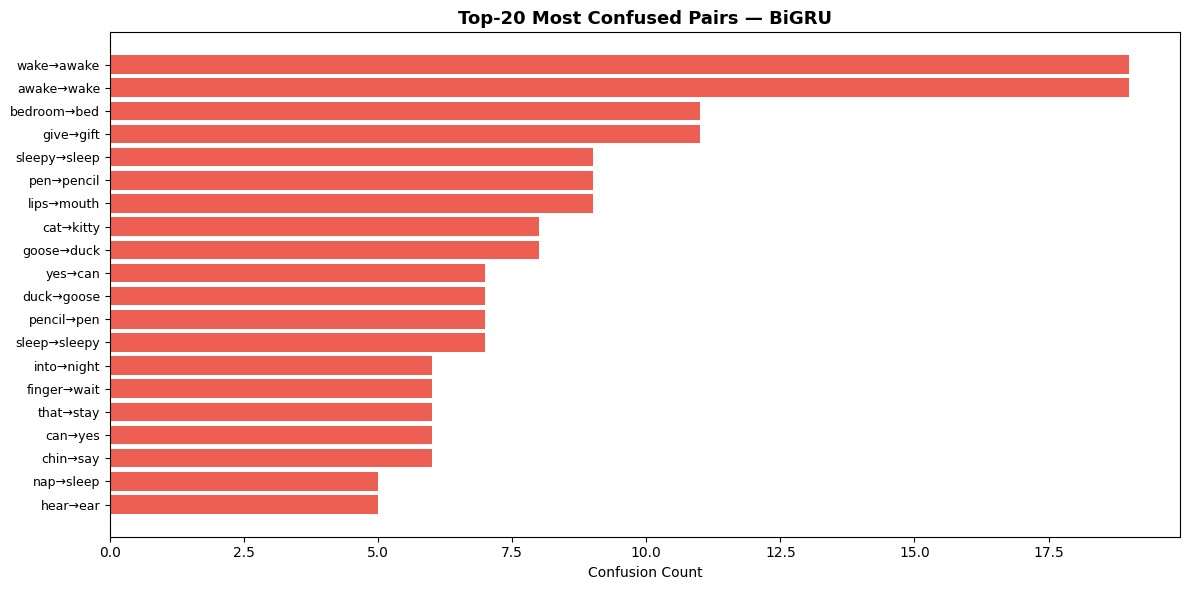

[2026-04-13 12:10:14] [BiGRU] [INFO]  Saved: /kaggle/working/BiGRU/plots/confused_pairs.png
[2026-04-13 12:10:14] [BiGRU] [INFO]  Hard examples (low-confidence correct) saved.


In [29]:
def error_analysis(y_true, y_pred, y_prob, class_names,
                   plots_dir, metrics_dir, model_name, dpi=300, top_pairs=20):
    wrong = y_true != y_pred
    wrong_true = y_true[wrong]; wrong_pred = y_pred[wrong]
    wrong_conf = y_prob[wrong][np.arange(wrong.sum()), wrong_pred]
    true_conf  = y_prob[wrong][np.arange(wrong.sum()), wrong_true]

    error_df = pd.DataFrame({
        "sample_index":    np.where(wrong)[0],
        "true_class":      [class_names[i] for i in wrong_true],
        "pred_class":      [class_names[i] for i in wrong_pred],
        "pred_confidence": wrong_conf,
        "true_confidence": true_conf,
    }).sort_values("pred_confidence", ascending=False)
    error_df.to_csv(os.path.join(metrics_dir, "misclassified_samples.csv"), index=False)
    logger.info("Errors: %d / %d  (%.2f%%)", wrong.sum(), len(y_true), 100*wrong.mean())

    # Confused pairs
    pair_counts = {}
    for t, p in zip(wrong_true, wrong_pred):
        pair_counts[(class_names[t], class_names[p])] =             pair_counts.get((class_names[t], class_names[p]), 0) + 1
    top_list = sorted(pair_counts.items(), key=lambda x: x[1], reverse=True)[:top_pairs]
    pd.DataFrame([(a,b,c) for (a,b),c in top_list],
                 columns=["true_class","pred_class","count"])       .to_csv(os.path.join(metrics_dir, "confused_pairs.csv"), index=False)
    if top_list:
        fig, ax = plt.subplots(figsize=(12, 6))
        labels = [f"{a}→{b}" for (a,b),_ in top_list]
        counts = [c for _,c in top_list]
        ax.barh(range(len(labels)), counts, color="#EA4335", alpha=0.85)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
        ax.set_xlabel("Confusion Count"); ax.invert_yaxis()
        ax.set_title(f"Top-{top_pairs} Most Confused Pairs — {model_name}",
                     fontsize=13, fontweight="bold")
        plt.tight_layout()
        path = os.path.join(plots_dir, "confused_pairs.png")
        plt.savefig(path, dpi=dpi, bbox_inches="tight"); plt.show()
        logger.info("Saved: %s", path)

    # Hard examples (correct but low confidence)
    correct_mask = ~wrong
    correct_conf = y_prob[correct_mask][np.arange(correct_mask.sum()), y_true[correct_mask]]
    hard_order   = np.argsort(correct_conf)[:50]
    pd.DataFrame({
        "sample_index": np.where(correct_mask)[0][hard_order],
        "true_class":   [class_names[y_true[np.where(correct_mask)[0][i]]] for i in hard_order],
        "confidence":   correct_conf[hard_order],
    }).to_csv(os.path.join(metrics_dir, "hard_examples.csv"), index=False)
    logger.info("Hard examples (low-confidence correct) saved.")
    return error_df

if y_true is not None:
    try:
        error_df = error_analysis(
            y_true, y_pred, y_prob, class_names,
            EVAL_CFG.PLOTS_DIR, EVAL_CFG.METRICS_DIR,
            EVAL_CFG.MODEL_NAME, dpi=EVAL_CFG.DPI)
    except Exception as e:
        logger.error("Error analysis failed: %s", e)
        error_df = None


## Section 28 — Comprehensive Evaluation Summary

All scalar metrics in one place — saved as **CSV** and **TXT**.

In [30]:
# accuracy_score and f1_score are already imported in Section 2
from sklearn.metrics import top_k_accuracy_score

def compute_summary(y_true, y_pred, y_prob, class_names,
                    macro_auc=None, macro_pr_auc=None, top_k=5,
                    model_name="model", metrics_dir=None, reports_dir=None):
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_wt  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    try:
        topk = top_k_accuracy_score(y_true, y_prob, k=top_k,
                                    labels=range(len(class_names)))
    except Exception:
        topk = float("nan")

    summary = {
        "model":            model_name,
        "accuracy":         round(acc,   4),
        f"top_{top_k}_acc": round(topk,  4),
        "macro_f1":         round(f1_mac, 4),
        "weighted_f1":      round(f1_wt,  4),
        "macro_roc_auc":    round(float(macro_auc),    4) if macro_auc    is not None else None,
        "macro_pr_auc":     round(float(macro_pr_auc), 4) if macro_pr_auc is not None else None,
        "n_classes":        len(class_names),
        "n_test_samples":   len(y_true),
    }
    line  = "=" * 58
    txt   = f"\n{line}\n  EVALUATION SUMMARY — {model_name}\n{line}\n"
    txt  += "\n".join(f"  {k:<22}: {v}" for k, v in summary.items())
    txt  += f"\n{line}\n"
    print(txt); logger.info(txt)

    if metrics_dir:
        pd.DataFrame([summary]).to_csv(
            os.path.join(metrics_dir, "evaluation_summary.csv"), index=False)
        logger.info("Evaluation summary CSV saved.")
    if reports_dir:
        with open(os.path.join(reports_dir, "evaluation_summary.txt"), "w") as f:
            f.write(txt)

    # Append to global comparison CSV
    try:
        comp = pd.read_csv(CFG.COMPARISON_CSV) if os.path.exists(CFG.COMPARISON_CSV)                else pd.DataFrame()
        comp = comp[comp["model"] != model_name] if "model" in comp.columns else comp
        pd.concat([comp, pd.DataFrame([summary])], ignore_index=True)           .to_csv(CFG.COMPARISON_CSV, index=False)
        logger.info("Global comparison CSV updated.")
    except Exception as exc:
        logger.warning("Could not update comparison CSV: %s", exc)
    return summary

if y_true is not None:
    try:
        eval_summary = compute_summary(
            y_true, y_pred, y_prob, class_names,
            macro_auc    = macro_auc    if "macro_auc"    in dir() else None,
            macro_pr_auc = macro_pr_auc if "macro_pr_auc" in dir() else None,
            top_k        = EVAL_CFG.TOP_K,
            model_name   = EVAL_CFG.MODEL_NAME,
            metrics_dir  = EVAL_CFG.METRICS_DIR,
            reports_dir  = EVAL_CFG.REPORTS_DIR)
    except Exception as e:
        logger.error("Summary failed: %s", e)
        eval_summary = None



  EVALUATION SUMMARY — BiGRU
  model                 : BiGRU
  accuracy              : 0.8159
  top_5_acc             : 0.9355
  macro_f1              : 0.8136
  weighted_f1           : 0.8157
  macro_roc_auc         : 0.9881
  macro_pr_auc          : 0.841
  n_classes             : 250
  n_test_samples        : 9344

[2026-04-13 12:10:14] [BiGRU] [INFO]  
  EVALUATION SUMMARY — BiGRU
  model                 : BiGRU
  accuracy              : 0.8159
  top_5_acc             : 0.9355
  macro_f1              : 0.8136
  weighted_f1           : 0.8157
  macro_roc_auc         : 0.9881
  macro_pr_auc          : 0.841
  n_classes             : 250
  n_test_samples        : 9344

[2026-04-13 12:10:14] [BiGRU] [INFO]  Evaluation summary CSV saved.
[2026-04-13 12:10:14] [BiGRU] [INFO]  Global comparison CSV updated.


## Section 28b — Model Comparison Dashboard

Reads `CFG.COMPARISON_CSV`, which is updated automatically each time Section 28
runs for any model.  When two or more models have been evaluated, a side-by-side
bar chart is produced and saved.  If only one model is registered, a summary
table is displayed instead.  No pipeline state is modified.

In [31]:
# =============================================================================
# Section 28b — Model Comparison Dashboard
# Reads the global comparison CSV; no pipeline state is modified.
# =============================================================================

# Fixed colour palette — consistent across all comparison plots
COMPARISON_PALETTE = [
    "#4285F4",   # Google Blue
    "#EA4335",   # Google Red
    "#34A853",   # Google Green
    "#FBBC05",   # Google Yellow
    "#9B59B6",   # Purple
    "#1ABC9C",   # Teal
    "#E67E22",   # Orange
    "#2C3E50",   # Dark Navy
]


def plot_model_comparison(csv_path, plots_dir, dpi=300):
    """
    Load the comparison CSV and render a grouped bar chart.
    Falls back to a text table if only one model is present.
    """
    if not os.path.exists(csv_path):
        logger.info("Comparison CSV not found at %s — no previous runs to compare.", csv_path)
        return

    df = pd.read_csv(csv_path)
    if df.empty:
        logger.info("Comparison CSV is empty.")
        return

    logger.info("Model comparison — %d model(s) registered.", len(df))

    # ── Tabular summary (always shown) ────────────────────────────────────────
    display_cols = [c for c in
                    ["model", "accuracy", "top_5_acc", "macro_f1",
                     "weighted_f1", "macro_roc_auc", "macro_pr_auc"]
                    if c in df.columns]
    line = "=" * 70
    print(f"\n{line}\n  Model Comparison Summary\n{line}")
    print(df[display_cols].to_string(index=False))
    print(f"{line}\n")

    if len(df) < 2:
        logger.info("Only one model registered — bar chart requires >= 2 entries.")
        return

    # ── Grouped bar chart ─────────────────────────────────────────────────────
    metric_cols = [c for c in
                   ["accuracy", "macro_f1", "macro_roc_auc", "macro_pr_auc"]
                   if c in df.columns]
    n_metrics = len(metric_cols)
    n_models  = len(df)
    x         = np.arange(n_metrics)
    bar_width  = 0.75 / n_models

    fig, ax = plt.subplots(figsize=(max(10, 3 * n_metrics), 6))

    for i, (_, row) in enumerate(df.iterrows()):
        offset = (i - (n_models - 1) / 2) * bar_width
        vals   = [row[m] for m in metric_cols]
        bars   = ax.bar(
            x + offset, vals,
            width=bar_width * 0.9,
            color=COMPARISON_PALETTE[i % len(COMPARISON_PALETTE)],
            label=str(row["model"]),
            alpha=0.88,
        )
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{v:.4f}",
                ha="center", va="bottom",
                fontsize=7, fontweight="bold",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [m.replace("_", " ").title() for m in metric_cols], fontsize=11
    )
    ax.set_ylabel("Score", fontsize=12)
    ax.set_ylim(0, 1.10)
    ax.set_title("Model Comparison — Key Metrics", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10, loc="lower right", framealpha=0.9)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()

    path = os.path.join(plots_dir, "model_comparison.png")
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    logger.info("Model comparison chart saved: %s", path)


try:
    plot_model_comparison(CFG.COMPARISON_CSV, EVAL_CFG.PLOTS_DIR, dpi=EVAL_CFG.DPI)
except Exception as e:
    logger.error("Model comparison dashboard failed: %s", e)


[2026-04-13 12:10:14] [BiGRU] [INFO]  Model comparison — 1 model(s) registered.

  Model Comparison Summary
model  accuracy  top_5_acc  macro_f1  weighted_f1  macro_roc_auc  macro_pr_auc
BiGRU    0.8159     0.9355    0.8136       0.8157         0.9881         0.841

[2026-04-13 12:10:14] [BiGRU] [INFO]  Only one model registered — bar chart requires >= 2 entries.


## Section 29 — Save Predictions

One row per test sample: true label, predicted label, correctness, confidence,
and the full 250-dimensional softmax probability vector.

In [32]:
def save_predictions_csv(y_true, y_pred, y_prob, class_names, predictions_dir):
    prob_cols = {f"prob_{class_names[c]}": y_prob[:, c] for c in range(len(class_names))}
    pred_df   = pd.DataFrame({
        "true_class":  [class_names[i] for i in y_true],
        "pred_class":  [class_names[i] for i in y_pred],
        "correct":     (y_true == y_pred).astype(int),
        "confidence":  y_prob[np.arange(len(y_pred)), y_pred],
        **prob_cols,
    })
    path = os.path.join(predictions_dir, "test_predictions.csv")
    pred_df.to_csv(path, index=False)
    logger.info("Predictions saved: %s  (%d rows)", path, len(pred_df))
    return pred_df

if y_true is not None and EVAL_CFG.SAVE_OUTPUTS:
    try:
        pred_df = save_predictions_csv(
            y_true, y_pred, y_prob, class_names, EVAL_CFG.PREDICTIONS_DIR)
        display(pred_df[["true_class","pred_class","correct","confidence"]].head(10))
    except Exception as e:
        logger.error("Saving predictions failed: %s", e)
        pred_df = None


[2026-04-13 12:10:17] [BiGRU] [INFO]  Predictions saved: /kaggle/working/BiGRU/predictions/test_predictions.csv  (9344 rows)


,true_class,pred_class,correct,confidence
0,pen,pen,1,10.288069
1,where,where,1,9.828931
2,toy,toy,1,8.953344
3,beside,have,0,7.773554
4,frenchfries,frenchfries,1,10.477247
5,brown,brown,1,9.272233
6,make,hide,0,7.442641
7,puppy,puppy,1,7.292984
8,closet,closet,1,8.512925
9,scissors,scissors,1,7.466905


## Section 30 — Output Directory Tree

Final inventory of every generated artefact with file sizes.

In [33]:
def print_output_tree(root):
    total = 0
    line  = "=" * 60
    print(f"\n{line}\n  OUTPUT ARTEFACTS — {EVAL_CFG.MODEL_NAME}\n{line}")
    for dirpath, _, filenames in os.walk(root):
        level     = dirpath.replace(root, "").count(os.sep)
        indent    = "  " * level
        rel_dir   = os.path.relpath(dirpath, root)
        print(f"{indent}[DIR]  {rel_dir}/")
        for fname in sorted(filenames):
            fpath = os.path.join(dirpath, fname)
            size  = os.path.getsize(fpath)
            total += size
            print(f"{indent}  [F]   {fname}  ({size/1024:.1f} KB)")
    print(f"{line}\n  Total: {total/1024**2:.2f} MB\n{line}")

try:
    print_output_tree(EVAL_CFG.OUTPUT_ROOT)
    logger.info("Evaluation pipeline complete.")
except Exception as e:
    logger.error("Output tree failed: %s", e)



  OUTPUT ARTEFACTS — BiGRU
[DIR]  ./
  [DIR]  reports/
    [F]   classification_report.txt  (13.5 KB)
    [F]   evaluation_summary.txt  (0.5 KB)
  [DIR]  predictions/
    [F]   test_predictions.csv  (24977.4 KB)
  [DIR]  logs/
    [F]   BiGRU_20260413_115009.log  (7.2 KB)
  [DIR]  checkpoints/
  [DIR]  metrics/
    [F]   classification_report.csv  (15.4 KB)
    [F]   confused_pairs.csv  (0.3 KB)
    [F]   dataset_report.txt  (0.7 KB)
    [F]   evaluation_summary.csv  (0.2 KB)
    [F]   hard_examples.csv  (1.0 KB)
    [F]   inference_performance.csv  (0.2 KB)
    [F]   misclassified_samples.csv  (59.8 KB)
    [F]   model_size.csv  (0.1 KB)
    [F]   per_class_accuracy.csv  (5.6 KB)
    [F]   pr_auc_per_class.csv  (6.0 KB)
    [F]   roc_auc_per_class.csv  (6.0 KB)
  [DIR]  plots/
    [F]   confused_pairs.png  (167.5 KB)
    [F]   confusion_matrix_normalized.png  (532.4 KB)
    [F]   confusion_matrix_raw.png  (532.4 KB)
    [F]   data_split_distribution.png  (191.6 KB)
    [F]   metrics_